Modelo completo
Integracion de:
1. Modelos de absorcion
2. Diseño de torre empirico
3. Celda electroquímica


KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.410 1/s | G_molar=2.053e+03 mol/s | (KGa/G)*dz = 0.00
KGa=323.

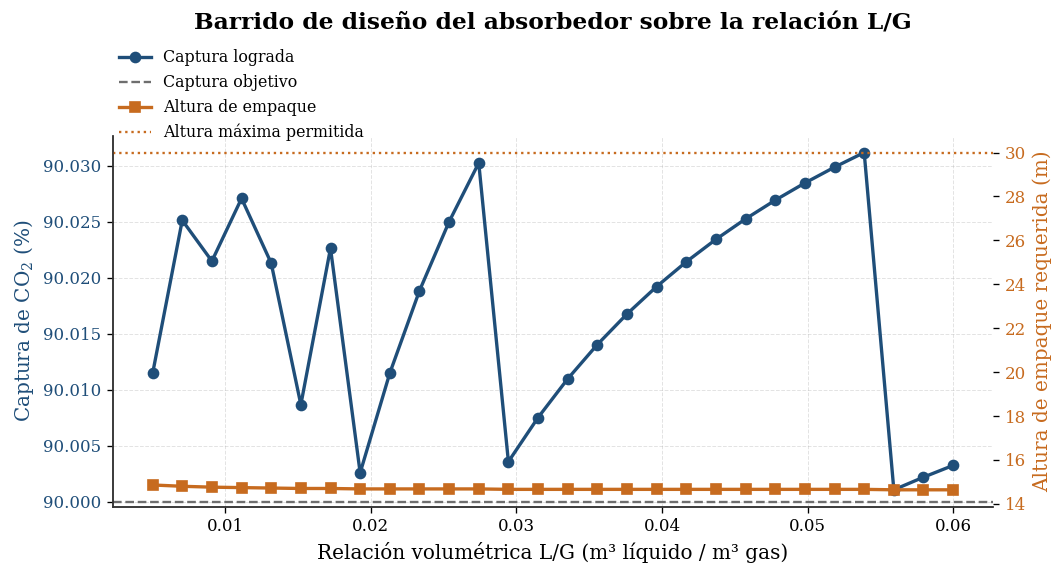

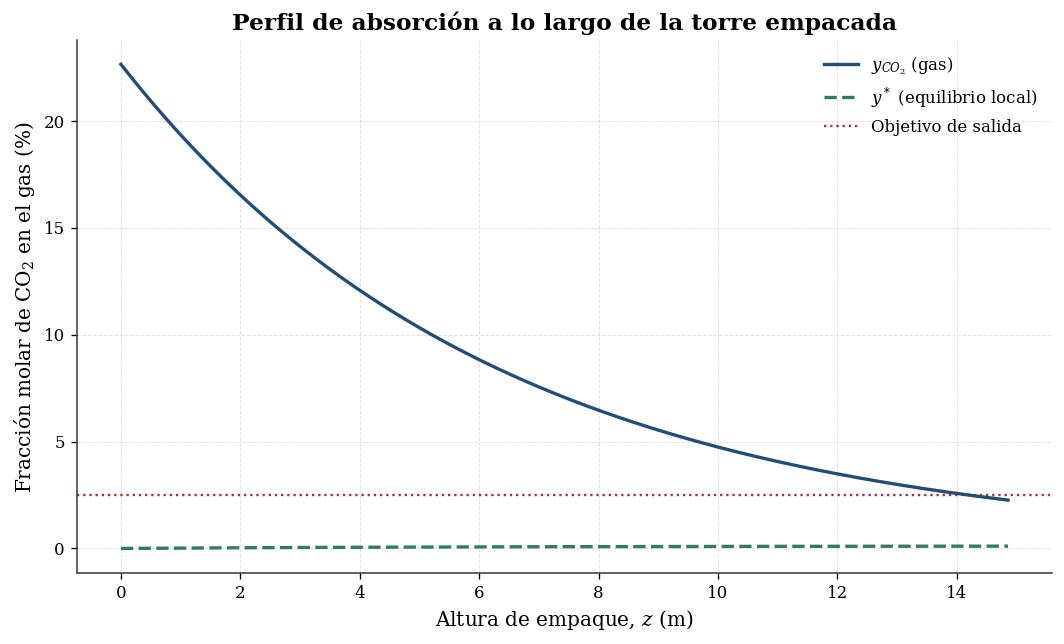

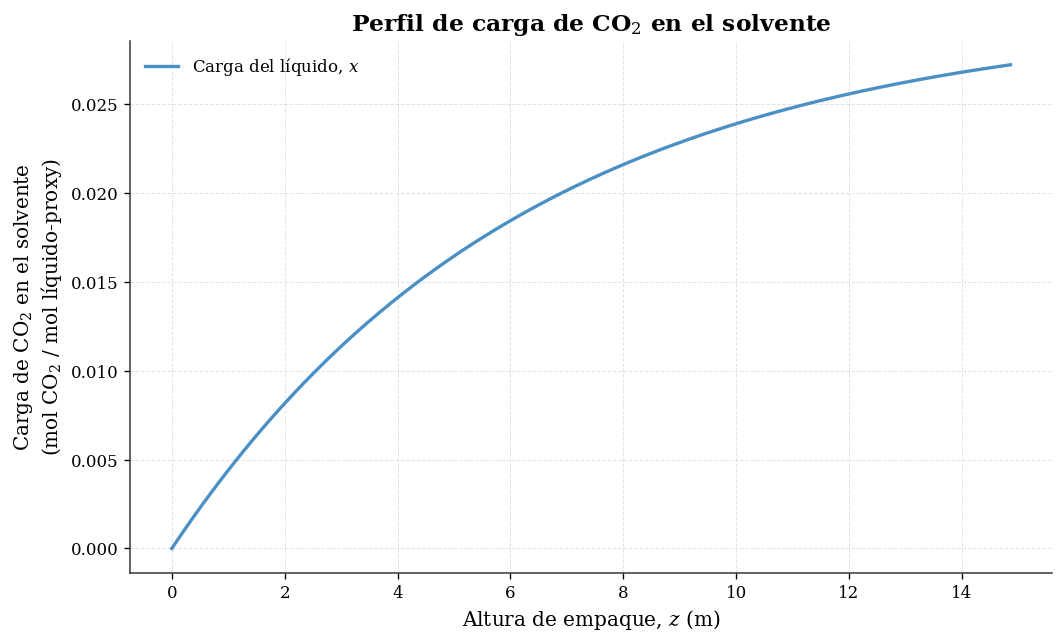

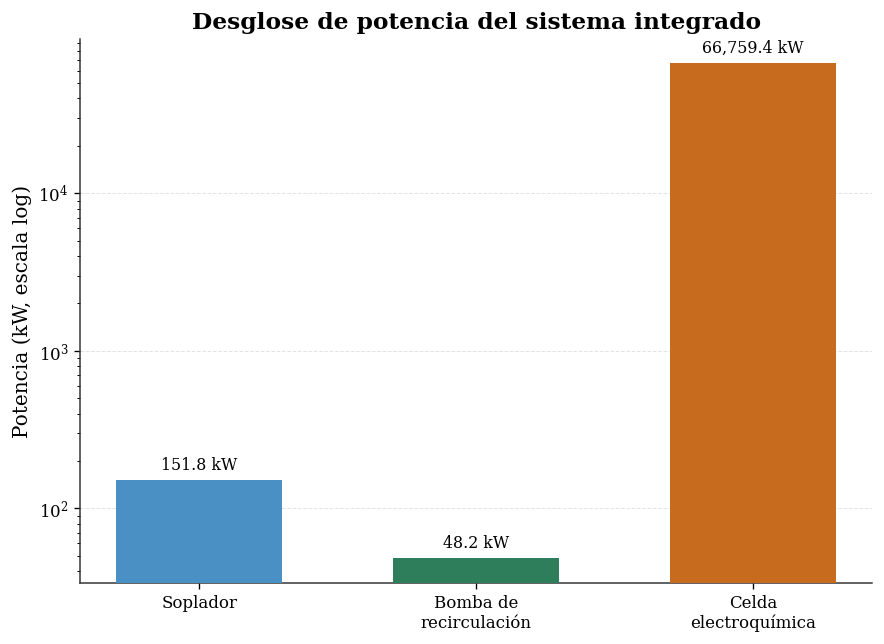

In [91]:

import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

def configurar_estilo_tesis():
    """Aplica un estilo tipográfico y de color consistente a todas las figuras."""
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.edgecolor": "#333333",
        "axes.linewidth": 0.9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "legend.frameon": False,
        "grid.color": "#B0B0B0",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "grid.alpha": 0.35,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
    })

PALETA = {
    "azul": "#1f4e79", "azul_claro": "#4a90c4", "verde": "#2e7d5b",
    "naranja": "#c76b1f", "rojo": "#a6303f", "gris": "#6e6e6e", "dorado": "#b8860b",
}

configurar_estilo_tesis()

# ============================================================
# 0) CASE STUDY INPUTS — edit these first
# ============================================================

# Cement plant case study (default from our discussion)
Qg_Nm3h = 150000.0          # dry flue gas flow, Nm3/h
yCO2_dry_in = 0.25          # dry mole fraction CO2
yO2_dry_in  = 0.03          # dry mole fraction O2
T_gas_abs_C = 45.0          # absorber inlet gas temperature, °C
P_abs_bar    = 1.01         # absorber pressure, bar
capture_target = 0.90       # target CO2 capture fraction
yCO2_out_target = yCO2_dry_in * (1.0 - capture_target)

# Solvent / reaction
NaOH_conc_M = 1.5           # circulating solvent NaOH concentration, mol/L
solvent_density_kgm3 = 1020 # approximate NaOH solution density, kg/m3
H_eq = 0.04                 # effective equilibrium slope y* = H_eq * X  (tunable)
liquid_resistance_factor = 0.001  # smaller = more reactive absorber, tune if needed
k2_CO2_OH_M = 8.5e3         # CO2 + OH- second-order rate constant, L/mol/s (approx @25°C)

# Packed column / hydraulics
packing_name = "pall_ring_25mm"
max_column_height_m = 30.0
min_freeboard_m = 1.5
design_flood_fraction = 0.60
blowdown_margin_factor = 1.15

# Electrochemical regeneration
j_cell_mAcm2 = 200.0        # chosen current density for cell design
cell_voltage_override_V = None  # if None, infer from j
tna_mode = "empirical"      # "empirical" or "const"
tna_const = 0.90
CO2_release_eff = 0.98      # fraction of captured CO2 released in product stream
cell_faradaic_eff = 0.98    # assume product gas purity / recovery
pump_eff = 0.70
blower_eff = 0.68

# Numerical controls
dz_m = 0.02
L_over_G_grid = np.linspace(0.005, 0.060, 28)  # m3 liquid / m3 gas
verbose = True

# ============================================================
# 1) CONSTANTS
# ============================================================

R = 8.31446261815324  # J/mol/K
FARADAY = 96485.3329  # C/mol
P_STD = 101325.0      # Pa
T_STD = 273.15        # K

MW = {
    "CO2": 44.01e-3,
    "N2": 28.0134e-3,
    "O2": 31.9988e-3,
    "H2O": 18.01528e-3,
    "air": 28.97e-3,
    "water": 18.01528e-3,
    "NaOH": 40.00e-3,
}

# ============================================================
# 2) PACKING DATABASE (simple, adjustable)
# ============================================================

PACKINGS = {
    "raschig_metal_25mm": {
        "a_spec_m2m3": 200.0,
        "void_fraction": 0.94,
        "dp_eq_m": 0.025,
        "wetting_ref_uLm_s": 0.003,
        "flood_coeff": 0.42,
    },
    "pall_ring_25mm": {
        "a_spec_m2m3": 210.0,
        "void_fraction": 0.92,
        "dp_eq_m": 0.025,
        "wetting_ref_uLm_s": 0.003,
        "flood_coeff": 0.45,
    },
    "structured_250Y": {
        "a_spec_m2m3": 250.0,
        "void_fraction": 0.97,
        "dp_eq_m": 0.008,
        "wetting_ref_uLm_s": 0.0015,
        "flood_coeff": 0.60,
    },
    "random_high_capacity": {
        "a_spec_m2m3": 160.0,
        "void_fraction": 0.95,
        "dp_eq_m": 0.035,
        "wetting_ref_uLm_s": 0.004,
        "flood_coeff": 0.40,
    }
}

# ============================================================
# 3) THERMOPHYSICAL PROPERTIES / HELPERS
# ============================================================


def c_to_k(T_C):
    return T_C + 273.15

def sat_vapor_pressure_water_Pa(T_K):
    """
    Antoine equation for water (valid roughly 1-100 C).
    Returns saturation pressure in Pa.
    """
    T_C = T_K - 273.15
    A, B, C = 8.07131, 1730.63, 233.426  # mmHg
    P_mmHg = 10 ** (A - B / (T_C + C))
    return P_mmHg * 133.322368

def dry_mole_flows_from_Nm3h(Q_Nm3h):
    """
    1 Nm3 at 0°C and 1 atm contains 44.615 mol.
    """
    return Q_Nm3h * 44.615 / 3600.0  # mol/s

def wet_gas_composition_from_dry(yCO2_dry, yO2_dry, T_K, P_Pa, yH2O_cap=None):
    """
    Convert dry gas composition to wet basis assuming humidification to a cap
    or saturation at absorber temperature.
    """
    yH2O_sat = min(0.25, sat_vapor_pressure_water_Pa(T_K) / P_Pa)
    yH2O = yH2O_sat if yH2O_cap is None else min(yH2O_cap, yH2O_sat)
    scale = 1.0 - yH2O
    yCO2_wet = yCO2_dry * scale
    yO2_wet = yO2_dry * scale
    yN2_wet = max(0.0, 1.0 - yCO2_wet - yO2_wet - yH2O)
    total = yCO2_wet + yO2_wet + yN2_wet + yH2O
    return {
        "CO2": yCO2_wet/total,
        "O2": yO2_wet/total,
        "N2": yN2_wet/total,
        "H2O": yH2O/total,
    }

def normalize_composition(comp):
    s = sum(comp.values())
    return {k: v/s for k, v in comp.items()}

def gas_mean_mw(comp):
    return sum(MW[k] * y for k, y in comp.items())

def gas_density_ideal(T_K, P_Pa, comp):
    MW_mix = gas_mean_mw(comp)
    return P_Pa * MW_mix / (R * T_K)

def gas_viscosity_sutherland_air(T_K):
    """
    Approx gas viscosity for flue gas ~ air.
    """
    mu0 = 1.716e-5
    T0 = 273.15
    S = 111.0
    return mu0 * ((T_K / T0) ** 1.5) * (T0 + S) / (T_K + S)

def gas_diffusivity_CO2_in_air(T_K, P_Pa):
    """
    Rough scaling for CO2-air diffusivity.
    """
    D_ref = 1.6e-5  # m2/s at 298 K, 1 atm
    return D_ref * (T_K / 298.15) ** 1.75 * (P_STD / P_Pa)

def liquid_viscosity_Pa_s(T_K, C_NaOH_M):
    """
    Very simplified: water viscosity corrected by NaOH concentration.
    """
    T_C = T_K - 273.15
    mu_water = 2.414e-5 * 10 ** (247.8 / (T_C + 133.15))
    return mu_water * (1.0 + 0.08 * C_NaOH_M)

def liquid_diffusivity_CO2_m2s(T_K, C_NaOH_M):
    """
    Approx diffusivity of CO2 in alkaline solution, decreases with concentration.
    """
    D0 = 1.9e-9 * (T_K / 298.15) ** 1.25
    return D0 / (1.0 + 0.30 * C_NaOH_M)

def liquid_density_kgm3(T_K, C_NaOH_M):
    """
    Approx density of NaOH solution near 1-2 M.
    """
    return 1000.0 + 24.0 * C_NaOH_M - 0.30 * (T_K - 298.15)

def superficial_velocity(Q_m3s, D_m):
    A = math.pi * D_m**2 / 4.0
    return Q_m3s / A

def reynolds(rho, u, d, mu):
    return rho * u * d / max(mu, 1e-12)

def schmidt(mu, rho, D):
    return mu / max(rho * D, 1e-18)

def sherwood_gas(Re, Sc):
    return 2.0 + 1.10 * (Re ** 0.70) * (Sc ** (1.0/3.0))

def sherwood_liquid(Re, Sc):
    return 2.0 + 1.10 * (Re ** 0.60) * (Sc ** (1.0/3.0))

def wetting_fraction(uL, packing):
    u_ref = packing["wetting_ref_uLm_s"]
    return float(np.clip(0.20 + 0.80 * (1.0 - np.exp(-uL / max(u_ref, 1e-9))), 0.20, 1.0))

def reaction_rate_constant_m3mol_s(T_K):
    """
    CO2 + OH- -> HCO3- effective rate constant in m3/mol/s.
    Input basis: 8.5e3 L/mol/s at 25C.
    """
    k2_L = k2_CO2_OH_M * (T_K / 298.15) ** 1.5
    return k2_L / 1000.0

def enhancement_factor_ha(Ha):
    Ha = max(Ha, 1e-12)
    if Ha < 50.0:
        return Ha / math.tanh(Ha)
    return Ha

def tna_empirical(C_NaOH_molm3, j_A_m2):
    """
    Empirical transference number model inspired by the notebook.
    Input C_NaOH in mol/m3.
    """
    C_M = C_NaOH_molm3 / 1000.0
    j_mAcm2 = j_A_m2 * 1e-1  # A/m2 -> mA/cm2
    t = 0.70 + 0.20 * (1.0 - math.exp(-4.0 * C_M))
    t -= 0.05 * min(j_mAcm2, 250.0) / 250.0
    return float(np.clip(t, 0.10, 0.98))

def voltage_from_current_density(j_A_m2):
    """
    Invert the notebook correlation:
    j [mA/cm2] = 604.92445 * exp(V/3.02912) - 767.22373
    """
    j_mAcm2 = j_A_m2 * 1e-1
    V = 3.02912 * math.log((j_mAcm2 + 767.22373) / 604.92445)
    return V

def energy_per_mol_CO2(V_cell, tna):
    """
    J/mol CO2 (assuming 1 e- per mol CO2 equivalent in the notebook logic)
    """
    return FARADAY * V_cell / max(tna, 1e-12)

def kL_kG_KGa(T_K, P_Pa, comp_gas, Qg_m3s, Ql_m3s, packing, C_NaOH_M, E=1.0):
    """
    Semi-mechanistic film model.
    Returns kL, kG, KGa and local hydraulics.
    """
    rho_g = gas_density_ideal(T_K, P_Pa, comp_gas)
    mu_g = gas_viscosity_sutherland_air(T_K)
    rho_l = liquid_density_kgm3(T_K, C_NaOH_M)
    mu_l = liquid_viscosity_Pa_s(T_K, C_NaOH_M)
    Dg = gas_diffusivity_CO2_in_air(T_K, P_Pa)
    Dl = liquid_diffusivity_CO2_m2s(T_K, C_NaOH_M)

    # hydraulic length from packing geometry
    eps = packing["void_fraction"]
    a_spec = packing["a_spec_m2m3"]
    d_h = 4.0 * eps / max(a_spec, 1e-12)

    # local superficial velocities based on a provisional area
    # use gas flow and a "not yet designed" area? here we need a local area estimate.
    # for coefficient estimation, choose a 1 m2 reference area and scale through Re.
    A_ref = 1
    uG = Qg_m3s / A_ref
    uL = max(Ql_m3s / A_ref, 1e-12)

    ReG = reynolds(rho_g, uG, d_h, mu_g)
    ReL = reynolds(rho_l, uL, d_h, mu_l)
    ScG = schmidt(mu_g, rho_g, Dg)
    ScL = schmidt(mu_l, rho_l, Dl)

    ShG = sherwood_gas(ReG, ScG)
    ShL = sherwood_liquid(ReL, ScL)

    kG = ShG * Dg / d_h
    kL = ShL * Dl / d_h

    wet = wetting_fraction(uL, packing)
    a_eff = a_spec * wet

    # overall coefficient with simple resistance combination.
    # H_eq is applied outside, so take a dimensionless slope factor separately.
    # kL is enhanced by E.
    KG = 1.0 / (1.0 / max(kG, 1e-12) + liquid_resistance_factor / max(kL * E, 1e-12))
    KGa = KG * a_eff

    return {
        "rho_g": rho_g, "mu_g": mu_g, "rho_l": rho_l, "mu_l": mu_l,
        "Dg": Dg, "Dl": Dl, "d_h": d_h,
        "uG": uG, "uL": uL, "ReG": ReG, "ReL": ReL, "ScG": ScG, "ScL": ScL,
        "ShG": ShG, "ShL": ShL, "kG": kG, "kL": kL, "a_eff": a_eff, "wet": wet,
        "KG": KG, "KGa": KGa
    }

def pressure_drop_Ergun_per_m(rho_g, mu_g, uG, packing):
    eps = packing["void_fraction"]
    dp = packing["dp_eq_m"]
    term1 = 150.0 * (1.0 - eps)**2 * mu_g * uG / max((eps**3) * dp**2, 1e-18)
    term2 = 1.75 * (1.0 - eps) * rho_g * uG**2 / max((eps**3) * dp, 1e-18)
    return term1 + term2

def flooding_velocity_simple(rho_g, rho_l, packing):
    eps = packing["void_fraction"]
    dp = packing["dp_eq_m"]
    C = packing["flood_coeff"]
    return C * math.sqrt(max((rho_l - rho_g), 1e-12) * 9.81 * dp / max(rho_g, 1e-12)) * (eps ** 0.15)

def choose_diameter(Qg_m3s, rho_g, rho_l, packing, flood_frac=0.60):
    v_flood = flooding_velocity_simple(rho_g, rho_l, packing)
    v_oper = max(0.05, flood_frac * v_flood)
    A = Qg_m3s / v_oper
    D = math.sqrt(4.0 * A / math.pi)
    return D, v_flood, v_oper

# ============================================================
# 4) ABSORBER MODEL
# ============================================================

def simulate_absorber(
    Qg_Nm3h,
    yCO2_dry_in,
    yO2_dry_in,
    T_gas_abs_C,
    P_abs_bar,
    capture_target,
    NaOH_conc_M,
    LG_vol,
    packing_name="pall_ring_25mm",
    H_eq=0.04,
    max_height_m=30.0,
    dz=0.02,
):
    """
    Returns a packed absorber profile using a semi-mechanistic rate model.
    """
    packing = PACKINGS[packing_name]
    T_K = c_to_k(T_gas_abs_C)
    P_Pa = P_abs_bar * 1e5

    # wet composition from dry basis + humidity
    comp_wet = wet_gas_composition_from_dry(yCO2_dry_in, yO2_dry_in, T_K, P_Pa)
    yCO2_wet_in = comp_wet["CO2"]
    yH2O = comp_wet["H2O"]
    # for absorption design, use wet basis because actual gas phase contains water
    y_in = yCO2_wet_in
    y_out_target = y_in * (1.0 - capture_target)

    # flows
    n_dry = dry_mole_flows_from_Nm3h(Qg_Nm3h)
    n_wet = n_dry / max(1.0 - yH2O, 1e-12)
    # total molar flow is conserved; convert to actual volumetric flow at absorber conditions
    Qg_actual_m3s = n_wet * R * T_K / P_Pa
    rho_g = gas_density_ideal(T_K, P_Pa, comp_wet)

    # initial guesses for area from flooding, then liquid flow from L/G
    # We will iterate on diameter and use it consistently to compute velocities and coefficients.
    # L/G is taken volumetrically based on actual gas flow at absorber conditions.
    Ql_m3s = LG_vol * Qg_actual_m3s
    rho_l = liquid_density_kgm3(T_K, NaOH_conc_M)
    D_col, v_flood, v_oper = choose_diameter(Qg_actual_m3s, rho_g, rho_l, packing, flood_frac=design_flood_fraction)
    A_col = math.pi * D_col**2 / 4.0
    uG = Qg_actual_m3s / A_col
    uL = Ql_m3s / A_col

    # update transfer coefficients with actual velocities and enhancement
    # pseudo-first-order reaction and Hatta number
    k2 = reaction_rate_constant_m3mol_s(T_K)
    OH_molm3 = NaOH_conc_M * 1000.0
    k1_pseudo = k2 * OH_molm3  # 1/s
    props0 = kL_kG_KGa(T_K, P_Pa, comp_wet, Qg_actual_m3s, Ql_m3s, packing, NaOH_conc_M, E=1.0)
    kL0 = props0["kL"]
    Dl = props0["Dl"]
    Ha = math.sqrt(max(k1_pseudo * Dl, 1e-24)) / max(kL0, 1e-12)
    E = enhancement_factor_ha(Ha)
    props = kL_kG_KGa(T_K, P_Pa, comp_wet, Qg_actual_m3s, Ql_m3s, packing, NaOH_conc_M, E=E)

    KGa = props["KGa"]
    kG = props["kG"]
    kL = props["kL"]
    a_eff = props["a_eff"]
    wet = props["wet"]

    # molar liquid flow approximation using water-equivalent molar mass
    M_liq_proxy = MW["water"]
    L_molar = rho_l * Ql_m3s / M_liq_proxy
    G_molar = n_wet  # mol/s

    # integrate along z
    z_vals = [0.0]
    y_vals = [y_in]
    x_vals = [0.0]            # loading, mol CO2/mol liquid-proxy
    E_vals = [E]
    Ha_vals = [Ha]
    KGa_vals = [KGa]
    ystar_vals = [H_eq * x_vals[-1]]
    rate_vals = [0.0]

    y = y_in
    x = 0.0
    reached = False
    z = 0.0

    numero_paso = (KGa / max(G_molar, 1e-12)) * dz
    print(f"KGa={KGa:.3f} 1/s | G_molar={G_molar:.3e} mol/s | (KGa/G)*dz = {numero_paso:.2f}")
    

    while z < max_height_m:
        y_star = H_eq * x
        driving0 = max(y - y_star, 0.0)

        # Paso analítico (estable para cualquier KGa, sin importar dz)
        tasa = (KGa / max(G_molar, 1e-12)) * dz
        y_new = y_star + (y - y_star) * math.exp(-tasa)
        y_new = max(y_new, 0.0)  # solo por seguridad numérica, ya no debería activarse

        # x se actualiza por balance de masa real, no por su propia derivada
        delta_y = y - y_new
        x_new = x + (G_molar / max(L_molar, 1e-12)) * delta_y

        z += dz
        y = y_new
        x = x_new

        z_vals.append(z)
        y_vals.append(y)
        x_vals.append(x)
        ystar_vals.append(H_eq * x)
        E_vals.append(E)
        Ha_vals.append(Ha)
        KGa_vals.append(KGa)
        rate_vals.append(KGa * driving0)

        if y <= y_out_target:
            reached = True
            break

    z_arr = np.array(z_vals)
    y_arr = np.array(y_vals)
    x_arr = np.array(x_vals)
    ystar_arr = np.array(ystar_vals)
    rate_arr = np.array(rate_vals)

    height_m = float(z_arr[-1]) if len(z_arr) > 0 else max_height_m
    capture_achieved = (y_in - y_arr[-1]) / max(y_in, 1e-12)

#    NTU = (KGa / max(G_molar, 1e-12)) * height_m
#    print(f"KGa={KGa:.2f} 1/s | G_molar={G_molar:.4e} mol/s | altura={height_m:.3f} m | NTU≈{NTU:.1f}")

    # pressure drop
    dpdz = pressure_drop_Ergun_per_m(props["rho_g"], props["mu_g"], uG, packing)
    deltaP = dpdz * height_m
    Qgas_actual = Qg_actual_m3s
    blower_power_W = deltaP * Qgas_actual / max(blower_eff, 1e-12)

    # pump power (simple recirculation estimate, head = 5 m + 0.5*H)
    pump_head_m = 5.0 + 0.5 * height_m
    pump_power_W = rho_l * 9.81 * pump_head_m * Ql_m3s / max(pump_eff, 1e-12)

    # in/out flowrates
    CO2_in_mol_s = G_molar * y_in
    CO2_out_mol_s = G_molar * y_arr[-1]
    CO2_captured_mol_s = max(CO2_in_mol_s - CO2_out_mol_s, 0.0)

    # stack residual concentration and treated gas purity proxy
    stack_CO2_ppmv = y_arr[-1] * 1e6
    treated_gas_purity = 1.0 - y_arr[-1]

    return {
        "packing": packing_name,
        "T_K": T_K, "P_Pa": P_Pa,
        "comp_wet_in": comp_wet,
        "yCO2_wet_in": y_in,
        "yCO2_out": y_arr[-1],
        "yCO2_out_target": y_out_target,
        "capture_achieved": capture_achieved,
        "reached_target": reached,
        "Qg_actual_m3s": Qg_actual_m3s,
        "Qg_actual_m3h": Qg_actual_m3s * 3600.0,
        "Ql_m3s": Ql_m3s,
        "Ql_m3h": Ql_m3s * 3600.0,
        "n_dry_mol_s": n_dry,
        "n_wet_mol_s": n_wet,
        "G_molar": G_molar,
        "L_molar": L_molar,
        "rho_g": rho_g,
        "rho_l": rho_l,
        "mu_g": props["mu_g"],
        "mu_l": props["mu_l"],
        "kG": kG,
        "kL": kL,
        "KGa": KGa,
        "a_eff": a_eff,
        "wetting_fraction": wet,
        "Ha": Ha,
        "E": E,
        "k1_pseudo": k1_pseudo,
        "D_g": props["Dg"],
        "D_l": props["Dl"],
        "ReG": props["ReG"],
        "ReL": props["ReL"],
        "ScG": props["ScG"],
        "ScL": props["ScL"],
        "uG": uG,
        "uL": uL,
        "D_col_m": D_col,
        "v_flood_m_s": v_flood,
        "v_oper_m_s": v_oper,
        "height_m": height_m,
        "dpdz_Pa_m": dpdz,
        "deltaP_Pa": deltaP,
        "blower_power_W": blower_power_W,
        "pump_power_W": pump_power_W,
        "CO2_in_mol_s": CO2_in_mol_s,
        "CO2_out_mol_s": CO2_out_mol_s,
        "CO2_captured_mol_s": CO2_captured_mol_s,
        "stack_CO2_ppmv": stack_CO2_ppmv,
        "treated_gas_purity": treated_gas_purity,
        "z_m": z_arr,
        "yCO2": y_arr,
        "x_loading": x_arr,
        "y_star": ystar_arr,
        "rate_indicator": rate_arr,
        "E_profile": np.full_like(z_arr, E, dtype=float),
        "Ha_profile": np.full_like(z_arr, Ha, dtype=float),
        "KGa_profile": np.full_like(z_arr, KGa, dtype=float),
    }

def design_absorber_by_grid(
    Qg_Nm3h,
    yCO2_dry_in,
    yO2_dry_in,
    T_gas_abs_C,
    P_abs_bar,
    capture_target,
    NaOH_conc_M,
    L_over_G_grid,
    packing_name="pall_ring_25mm",
    H_eq=0.04,
    max_height_m=30.0,
    dz=0.02,
    objective="min_total_power"
):
    """
    Scan L/G values and select a feasible design.
    """
    candidates = []
    for LG_vol in L_over_G_grid:
        res = simulate_absorber(
            Qg_Nm3h=Qg_Nm3h,
            yCO2_dry_in=yCO2_dry_in,
            yO2_dry_in=yO2_dry_in,
            T_gas_abs_C=T_gas_abs_C,
            P_abs_bar=P_abs_bar,
            capture_target=capture_target,
            NaOH_conc_M=NaOH_conc_M,
            LG_vol=float(LG_vol),
            packing_name=packing_name,
            H_eq=H_eq,
            max_height_m=max_height_m,
            dz=dz
        )
        total_power_W = res["blower_power_W"] + res["pump_power_W"]
        # electrochemical area and power handled later
        res["total_hydraulic_power_W"] = total_power_W
        candidates.append(res)

    feasible = [r for r in candidates if r["reached_target"] and r["height_m"] <= max_height_m]
    if len(feasible) == 0:
        # choose the best capture achieved if target not met
        best = max(candidates, key=lambda r: (r["capture_achieved"], -r["height_m"]))
        best["feasible"] = False
    else:
        if objective == "min_total_power":
            best = min(feasible, key=lambda r: r["total_hydraulic_power_W"])
        elif objective == "min_height":
            best = min(feasible, key=lambda r: r["height_m"])
        else:
            best = min(feasible, key=lambda r: r["total_hydraulic_power_W"])
        best["feasible"] = True

    return best, candidates

# ============================================================
# 5) ELECTROCHEMICAL REGENERATION / CYCLING
# ============================================================

def electrochemical_regeneration(CO2_capture_mol_s, j_cell_mAcm2=200.0, NaOH_conc_M=1.5,
                                 tna_mode="empirical", tna_const=0.90,
                                 cell_voltage_override_V=None,
                                 CO2_release_eff=0.98):
    """
    Size the electrochemical cell and compute released CO2 and power demand.
    """
    j_A_m2 = j_cell_mAcm2 * 10.0  # 1 mA/cm2 = 10 A/m2
    C_NaOH_molm3 = NaOH_conc_M * 1000.0

    if tna_mode == "const":
        tna = float(tna_const)
    else:
        tna = tna_empirical(C_NaOH_molm3, j_A_m2)

    V_cell = voltage_from_current_density(j_A_m2) if cell_voltage_override_V is None else float(cell_voltage_override_V)
    E_mol_J = energy_per_mol_CO2(V_cell, tna)

    A_cell_m2 = CO2_capture_mol_s * FARADAY / max(tna * j_A_m2, 1e-12)
    J_cell_A = j_A_m2 * A_cell_m2
    P_cell_W = J_cell_A * V_cell
    CO2_released_mol_s = CO2_capture_mol_s * CO2_release_eff
    CO2_slip_mol_s = CO2_capture_mol_s - CO2_released_mol_s

    return {
        "j_A_m2": j_A_m2,
        "tna": tna,
        "V_cell": V_cell,
        "E_mol_J": E_mol_J,
        "A_cell_m2": A_cell_m2,
        "I_cell_A": J_cell_A,
        "P_cell_W": P_cell_W,
        "CO2_released_mol_s": CO2_released_mol_s,
        "CO2_slip_mol_s": CO2_slip_mol_s,
        "CO2_release_eff": CO2_release_eff,
    }

# ============================================================
# 6) MAIN EXECUTION + PLOTS
# ============================================================

def run_case():
    best, candidates = design_absorber_by_grid(
        Qg_Nm3h=Qg_Nm3h,
        yCO2_dry_in=yCO2_dry_in,
        yO2_dry_in=yO2_dry_in,
        T_gas_abs_C=T_gas_abs_C,
        P_abs_bar=P_abs_bar,
        capture_target=capture_target,
        NaOH_conc_M=NaOH_conc_M,
        L_over_G_grid=L_over_G_grid,
        packing_name=packing_name,
        H_eq=H_eq,
        max_height_m=max_column_height_m,
        dz=dz_m,
        objective="min_total_power"
    )

    regen = electrochemical_regeneration(
        CO2_capture_mol_s=best["CO2_captured_mol_s"],
        j_cell_mAcm2=j_cell_mAcm2,
        NaOH_conc_M=NaOH_conc_M,
        tna_mode=tna_mode,
        tna_const=tna_const,
        cell_voltage_override_V=cell_voltage_override_V,
        CO2_release_eff=CO2_release_eff
    )

    best["regen"] = regen
    best["P_total_W"] = best["blower_power_W"] + best["pump_power_W"] + regen["P_cell_W"]
    best["P_total_kW"] = best["P_total_W"] / 1000.0

    # annualized figures (continuous operation)
    sec_per_year = 365.0 * 24.0 * 3600.0
    best["CO2_captured_tpy"] = best["CO2_captured_mol_s"] * 44.01 * sec_per_year / 1e6
    best["CO2_stack_tpy"] = best["CO2_out_mol_s"] * 44.01 * sec_per_year / 1e6
    best["CO2_product_tpy"] = regen["CO2_released_mol_s"] * 44.01 * sec_per_year / 1e6
    best["E_cell_kWh_tCO2"] = (regen["P_cell_W"] / 1000.0) / max(best["CO2_captured_mol_s"] * 44.01 * 3600.0 / 1e6, 1e-12)
    best["E_cell_MWh_tCO2"] = best["E_cell_kWh_tCO2"] / 1000.0

    # Print results
    print("\n" + "="*80)
    print("INTEGRATED CO2 CAPTURE MODEL — ABSORBER + PACKED TOWER + ELECTROCHEMICAL REGENERATION")
    print("="*80)
    print(f"Feed gas: {Qg_Nm3h:,.0f} Nm3/h dry, yCO2(dry)={yCO2_dry_in:.3f}, yO2(dry)={yO2_dry_in:.3f}")
    print(f"Absorber T/P: {T_gas_abs_C:.1f} °C, {P_abs_bar:.3f} bar")
    print(f"Chosen packing: {packing_name}")
    print(f"NaOH concentration: {NaOH_conc_M:.2f} M")
    print(f"Target capture: {capture_target*100:.1f}%  | achieved: {best['capture_achieved']*100:.2f}%")
    print(f"Outlet CO2 (wet basis): {best['yCO2_out']*100:.3f}%  ({best['stack_CO2_ppmv']:.0f} ppmv)")
    print(f"Liquid circulation: {best['Ql_m3h']:.1f} m3/h")
    print(f"Gas actual flow in absorber: {best['Qg_actual_m3h']:.1f} m3/h")
    print(f"Column diameter: {best['D_col_m']:.2f} m")
    print(f"Packed height needed: {best['height_m']:.2f} m")
    print(f"Pressure drop: {best['deltaP_Pa']:.0f} Pa")
    print(f"Gas-side blowers: {best['blower_power_W']/1000:.1f} kW")
    print(f"Pump power: {best['pump_power_W']/1000:.1f} kW")
    print(f"Volumetric KGa: {best['KGa']:.4f} 1/s")
    print(f"kG: {best['kG']:.6f} m/s | kL: {best['kL']:.6f} m/s | wetting={best['wetting_fraction']:.2f}")
    print(f"Hatta number: {best['Ha']:.1f} | Enhancement factor E: {best['E']:.1f}")
    print(f"CO2 captured: {best['CO2_captured_mol_s']:.2f} mol/s = {best['CO2_captured_mol_s']*44.01/1000:.2f} kg/s")
    print(f"CO2 remaining in stack: {best['CO2_out_mol_s']*44.01/1000:.2f} kg/s")
    print(f"\nElectrochemical regeneration:")
    print(f"  j_cell = {regen['j_A_m2']:.0f} A/m2 ({j_cell_mAcm2:.0f} mA/cm2)")
    print(f"  t_Na = {regen['tna']:.3f}")
    print(f"  V_cell = {regen['V_cell']:.3f} V")
    print(f"  Cell area required = {regen['A_cell_m2']:.2f} m2")
    print(f"  Cell power = {regen['P_cell_W']/1000:.1f} kW")
    print(f"  CO2 released by cell = {regen['CO2_released_mol_s']:.2f} mol/s")
    print(f"  CO2 slip / unreleased = {regen['CO2_slip_mol_s']:.4f} mol/s")
    print(f"  Total power = {best['P_total_kW']:.1f} kW")
    print(f"  CO2 product from cell = {best['CO2_product_tpy']:.0f} t/y")
    print(f"  Captured CO2 = {best['CO2_captured_tpy']:.0f} t/y")
    print(f"  Residual stack CO2 = {best['CO2_stack_tpy']:.0f} t/y")
    print(f"  Cell energy intensity = {best['E_cell_kWh_tCO2']:.1f} kWh/tCO2  ({best['E_cell_MWh_tCO2']:.3f} MWh/tCO2)")
    print("="*80)

    # ------------------------------------------------------------
    # Plot 1: L/G scan summary
    # ------------------------------------------------------------
    LGs = np.array([r["Ql_m3h"] / max(r["Qg_actual_m3h"], 1e-12) for r in candidates])
    heights = np.array([r["height_m"] for r in candidates])
    caps = np.array([r["capture_achieved"] for r in candidates])
    powers = np.array([r["blower_power_W"] + r["pump_power_W"] for r in candidates]) / 1000.0
    feasible = np.array([r["reached_target"] and r["height_m"] <= max_column_height_m for r in candidates])

    fig, ax1 = plt.subplots(figsize=(9, 5.5))
    ax1.plot(LGs, caps * 100, marker="o", color=PALETA["azul"], label="Captura lograda", zorder=3)
    ax1.axhline(capture_target * 100, linestyle="--", color=PALETA["gris"], linewidth=1.4, label="Captura objetivo")
    ax1.set_xlabel("Relación volumétrica L/G (m³ líquido / m³ gas)")
    ax1.set_ylabel("Captura de CO$_2$ (%)", color=PALETA["azul"])
    ax1.tick_params(axis="y", labelcolor=PALETA["azul"])
    ax2 = ax1.twinx()
    ax2.plot(LGs, heights, marker="s", color=PALETA["naranja"], label="Altura de empaque", zorder=3)
    ax2.axhline(max_column_height_m, linestyle=":", color=PALETA["naranja"], linewidth=1.4, label="Altura máxima permitida")
    ax2.set_ylabel("Altura de empaque requerida (m)", color=PALETA["naranja"])
    ax2.tick_params(axis="y", labelcolor=PALETA["naranja"])
    ax2.grid(False)
    l1, e1 = ax1.get_legend_handles_labels()
    l2, e2 = ax2.get_legend_handles_labels()
    ax1.legend(
        l1 + l2,
        e1 + e2,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.25),
        ncol=1,
        fontsize=9.5,
        borderaxespad=0.0,
    )
    ax1.set_title("Barrido de diseño del absorbedor sobre la relación L/G", pad=64)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

    # ------------------------------------------------------------
    # Plot 2: Absorption profile along the column
    # ------------------------------------------------------------
    z = best["z_m"]
    y = best["yCO2"]
    x = best["x_loading"]
    ystar = best["y_star"]
    Eprof = best["E_profile"]
    KGaprof = best["KGa_profile"]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(z, y * 100, color=PALETA["azul"], label="$y_{CO_2}$ (gas)", zorder=3)
    ax.plot(z, ystar * 100, color=PALETA["verde"], linestyle="--", label="$y^*$ (equilibrio local)", zorder=3)
    ax.axhline(yCO2_out_target * 100, color=PALETA["rojo"], linestyle=":", linewidth=1.4, label="Objetivo de salida")
    ax.set_xlabel("Altura de empaque, $z$ (m)")
    ax.set_ylabel("Fracción molar de CO$_2$ en el gas (%)")
    ax.legend(loc="best")
    ax.set_title("Perfil de absorción a lo largo de la torre empacada")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(z, x, color=PALETA["azul_claro"], label="Carga del líquido, $x$", zorder=3)
    ax.set_xlabel("Altura de empaque, $z$ (m)")
    ax.set_ylabel("Carga de CO$_2$ en el solvente\n(mol CO$_2$ / mol líquido-proxy)")
    ax.legend(loc="best")
    ax.set_title("Perfil de carga de CO$_2$ en el solvente")
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 3: Energy breakdown
    # ------------------------------------------------------------
    etiquetas = ["Soplador", "Bomba de\nrecirculación", "Celda\nelectroquímica"]
    valores = [best["blower_power_W"] / 1000.0, best["pump_power_W"] / 1000.0, regen["P_cell_W"] / 1000.0]
    colores = [PALETA["azul_claro"], PALETA["verde"], PALETA["naranja"]]

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    barras = ax.bar(etiquetas, valores, color=colores, width=0.6, zorder=3)
    ax.set_yscale("log")  # la celda domina por ~400x; escala log hace visibles las tres barras
    ax.set_ylabel("Potencia (kW, escala log)")
    ax.set_title("Desglose de potencia del sistema integrado")
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")
    for barra, valor in zip(barras, valores):
        ax.annotate(f"{valor:,.1f} kW", xy=(barra.get_x() + barra.get_width() / 2, valor),
                    xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9.5)
    fig.tight_layout()
    plt.show()

    return best, candidates

    return best, candidates

# Run
best_design, all_designs = run_case()



=== DESIGN SUMMARY ===


,Metric,Value,Units
0,Gas flow,300000.000000,Nm3/h
1,Dry CO2 in flue gas,0.250000,-
2,Target capture,0.900000,-
3,Column diameter,4.186856,m
4,Packed height,25.000000,m
5,Annual CO2 captured,530094.862594,t/yr



=== CAPEX BREAKDOWN ===


,Item,USD
0,Shell,8.220873e+05
1,Packing,1.204687e+06
2,Internals,2.478212e+04
3,Column purchased,2.052171e+06
4,Column installed,3.386083e+06
5,Cell CAPEX,0.000000e+00
6,Blower CAPEX,0.000000e+00
7,Pump CAPEX,0.000000e+00
8,Total installed CAPEX,3.386083e+06



=== OPEX BREAKDOWN ===


,Item,USD/yr
0,Fixed O&M,1.354433e+05
1,Electricity,6.429865e+07
2,Solvent makeup,3.975711e+05
3,Water/chemicals,7.951423e+04
4,Total OPEX,6.491118e+07



=== LCOC / ELECTRICITY / CARBON SUMMARY ===
Annualized CAPEX:      $397,728 / yr
Annual OPEX:           $64,911,181 / yr
LCOC:                  $123.20 / tCO2 captured
Annual electricity:    535,822,105 kWh / yr
Grid EF default:       0.2104 kgCO2e / kWh
Indirect emissions:    112,737.0 tCO2e / yr
Indirect intensity:    212.67 kgCO2e / tCO2 captured


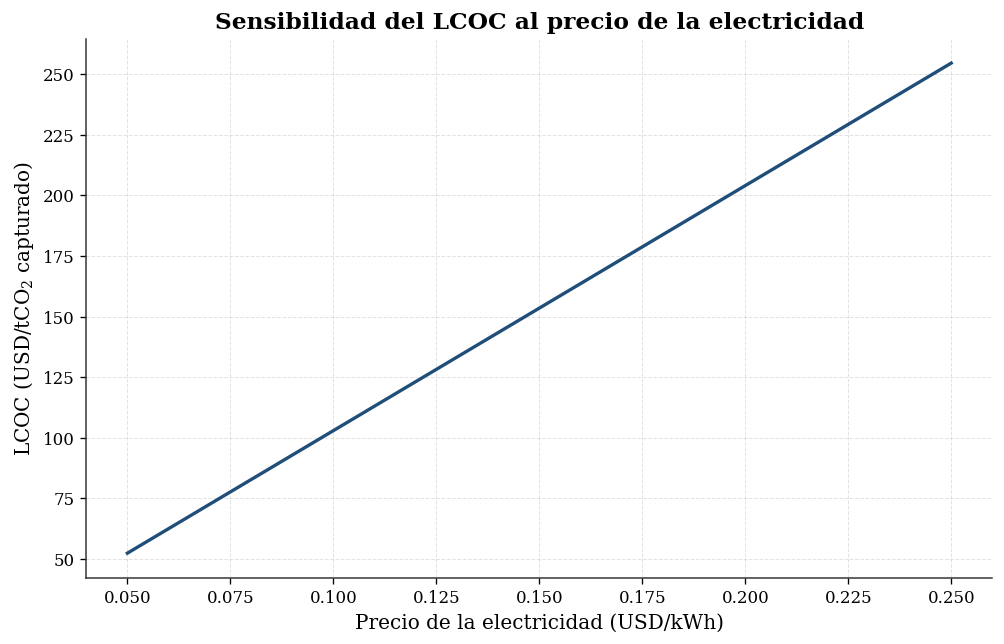

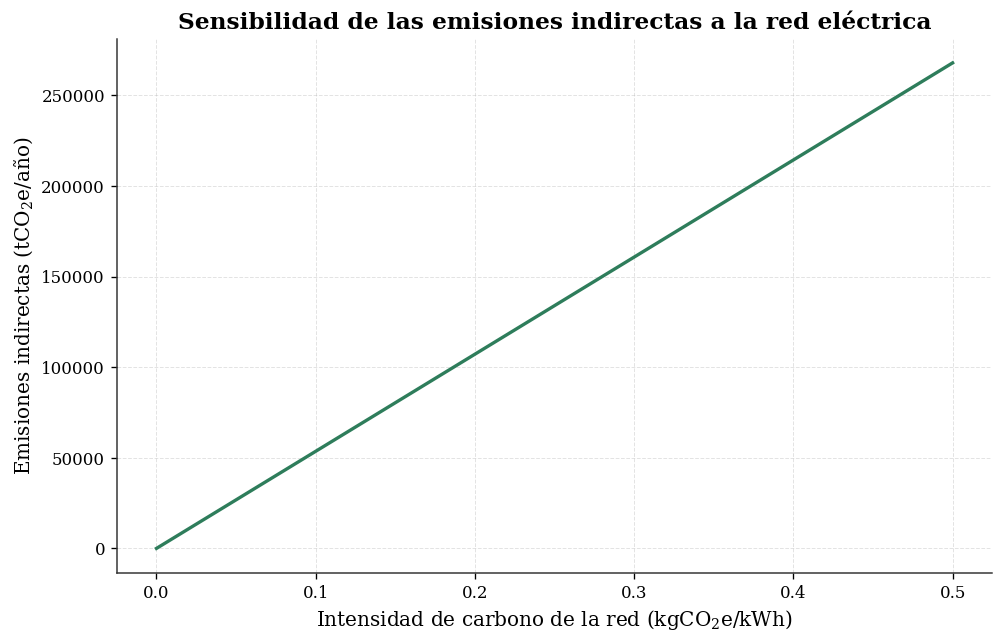

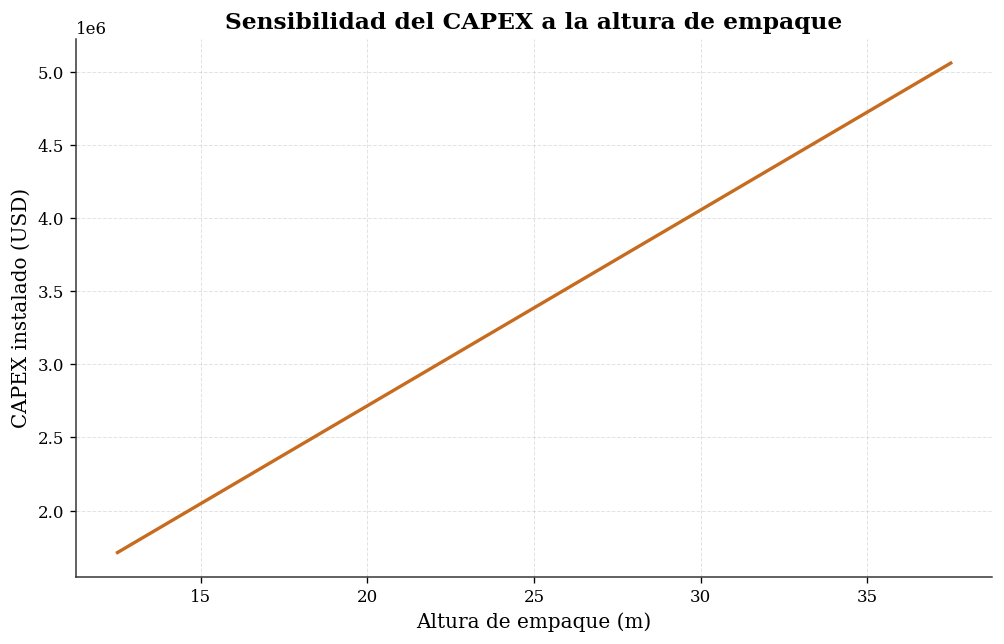

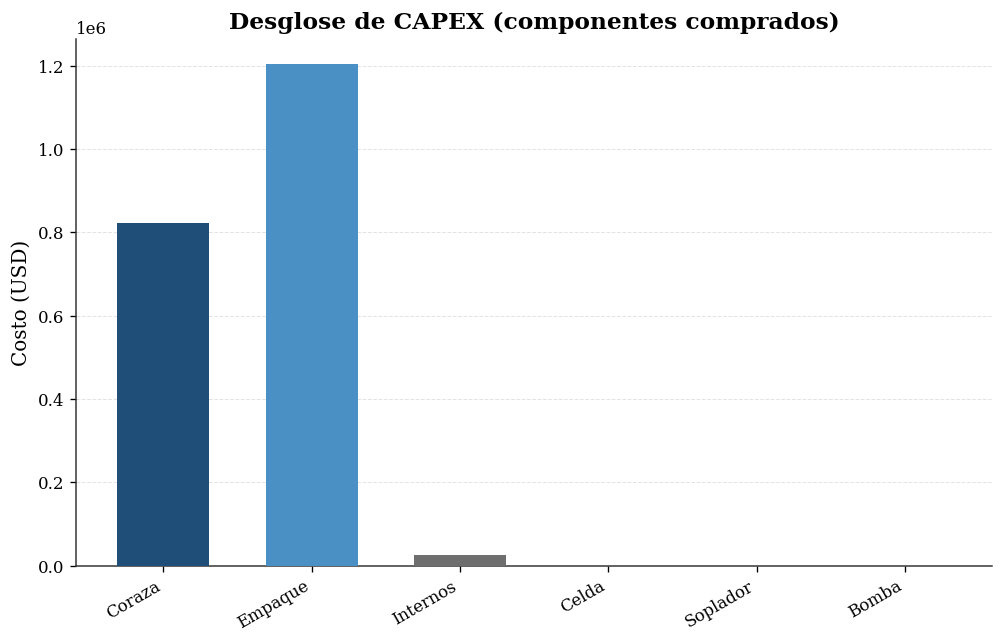

In [92]:
# ============================================================
# TEA / LCOC / CAPEX EXTENSION
# Pegar después de las celdas del modelo de absorción y celda
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 1) Parámetros editables
# -----------------------
hours_per_year = 8000.0          # horas operativas al año
discount_rate = 0.10             # tasa de descuento
project_life_years = 20          # años de vida útil económica

electricity_price_usd_per_kWh = 0.12
grid_emission_factor_kgCO2e_per_kWh = 0.2104  # Colombia por defecto; editable

fixed_om_fraction_of_installed_capex = 0.04   # O&M fijo como fracción del CAPEX instalado
solvent_makeup_usd_per_tCO2 = 0.75            # editable
water_and_chemicals_usd_per_tCO2 = 0.15       # editable

# Si el modelo previo no dejó potencia total, se usa este proxy
default_specific_electricity_kWh_per_tCO2 = 250.0  # solo fallback

# Si el modelo previo no dejó geometría, se usa esto como caso base
default_case = dict(
    Qg_Nm3h=300000.0,     # caudal de gas de cementera
    yCO2_dry=0.25,        # fracción molar de CO2 en base seca
    capture_target=0.90,   # objetivo de captura
    D_col_m=8.0,          # diámetro de torre
    H_packed_m=25.0,      # altura empacada
    pressure_bar=1.01,    # presión de operación
)

# -----------------------
# 2) Funciones auxiliares
# -----------------------
def crf(i, n):
    """Capital Recovery Factor."""
    return i * (1 + i)**n / ((1 + i)**n - 1)

def kmol_s_from_Nm3h(Q_Nm3h):
    """Convierte Nm3/h a kmol/s usando 22.414 Nm3/kmol."""
    return Q_Nm3h / 22.414 / 3600.0

def annual_tCO2_from_mol_s(n_CO2_mol_s, hours=8000.0):
    """Convierte un flujo molar de CO2 [mol/s] a tCO2/año."""
    return n_CO2_mol_s * 44.0e-3 * 3600.0 * hours / 1000.0

def estimate_absorber_capex_geometry(
    D_m,
    H_packed_m,
    pressure_bar=1.01,
    shell_cost_per_m2=2500.0,      # editable
    packing_cost_per_m3=3500.0,    # editable
    internals_cost_per_m2=1800.0,  # editable
    installation_factor=1.65,      # editable
):
    """
    Estimador preliminar de CAPEX para torre empacada.
    Comprado = shell + packing + internos
    Instalado = comprado * factor de instalación

    Esta forma es deliberadamente transparente: la altura entra por el área de
    coraza y por el volumen empacado, y el diámetro entra por área transversal
    y área lateral.
    """
    A_cs_m2 = math.pi * D_m**2 / 4.0
    shell_area_m2 = math.pi * D_m * H_packed_m
    packed_volume_m3 = A_cs_m2 * H_packed_m

    # Factor leve por presión (cerca de atm, prácticamente 1.0)
    pressure_factor = 1.0 + 0.03 * max(pressure_bar - 1.0, 0.0)

    shell_cost = shell_cost_per_m2 * shell_area_m2
    packing_cost = packing_cost_per_m3 * packed_volume_m3
    internals_cost = internals_cost_per_m2 * A_cs_m2

    purchased_cost = pressure_factor * (shell_cost + packing_cost + internals_cost)
    installed_cost = purchased_cost * installation_factor

    return {
        "A_cs_m2": A_cs_m2,
        "shell_area_m2": shell_area_m2,
        "packed_volume_m3": packed_volume_m3,
        "pressure_factor": pressure_factor,
        "shell_cost_usd": shell_cost,
        "packing_cost_usd": packing_cost,
        "internals_cost_usd": internals_cost,
        "purchased_cost_usd": purchased_cost,
        "installed_cost_usd": installed_cost,
    }

def safe_design_from_previous_cells():
    """
    Intenta leer variables del modelo previo.
    Si no existen, usa default_case.
    """
    design = dict(default_case)

    # contenedores frecuentes del notebook previo
    for container_name in ["best", "best_design", "design", "case"]:
        if container_name in globals() and isinstance(globals()[container_name], dict):
            design.update(globals()[container_name])

    # mapa de alias posibles
    key_map = {
        "Qg_Nm3h": ["Qg_Nm3h", "Qgas_Nm3h", "Q_Nm3h", "gas_flow_Nm3h", "Q_in_Nm3h"],
        "yCO2_dry": ["yCO2_dry", "CO2_dry", "y_in_CO2", "CO2_in_dry"],
        "capture_target": ["capture_target", "target_capture", "capture_goal", "eta_capture"],
        "D_col_m": ["D_col_m", "D_m", "diameter_m", "D_tower_m"],
        "H_packed_m": ["H_packed_m", "H_total_m", "H_m", "packed_height_m", "Z_m"],
        "pressure_bar": ["pressure_bar", "P_bar", "P_abs_bar"],
    }

    for std_key, candidates in key_map.items():
        for c in candidates:
            if c in design and design[c] is not None:
                try:
                    design[std_key] = float(design[c])
                    break
                except Exception:
                    pass

    return design

# -----------------------
# 3) Leer resultados del modelo previo
# -----------------------
case = safe_design_from_previous_cells()

Qg_Nm3h = float(case["Qg_Nm3h"])
yCO2_dry = float(case["yCO2_dry"])
capture_target = float(case["capture_target"])
D_col_m = float(case["D_col_m"])
H_packed_m = float(case["H_packed_m"])
pressure_bar = float(case["pressure_bar"])

# CO2 capturado: usar salida del modelo si existe, si no, usar aproximación del caso base
if "CO2_captured_mol_s" in case and case["CO2_captured_mol_s"] is not None:
    CO2_captured_mol_s = float(case["CO2_captured_mol_s"])
else:
    CO2_captured_mol_s = kmol_s_from_Nm3h(Qg_Nm3h) * 1000.0 * yCO2_dry * capture_target

annual_captured_tCO2 = annual_tCO2_from_mol_s(CO2_captured_mol_s, hours=hours_per_year)

# -----------------------
# 4) Potencia eléctrica anual
# -----------------------
P_total_W = None
for key in ["P_total_W", "total_power_W", "power_total_W"]:
    if key in case and case[key] is not None:
        try:
            P_total_W = float(case[key])
            break
        except Exception:
            pass

if P_total_W is None or P_total_W <= 0:
    annual_electricity_kWh = annual_captured_tCO2 * default_specific_electricity_kWh_per_tCO2
else:
    annual_electricity_kWh = (P_total_W / 1000.0) * hours_per_year

# -----------------------
# 5) CAPEX
# -----------------------
capex = estimate_absorber_capex_geometry(
    D_m=D_col_m,
    H_packed_m=H_packed_m,
    pressure_bar=pressure_bar,
    shell_cost_per_m2=2500.0,      # ajustable
    packing_cost_per_m3=3500.0,    # ajustable
    internals_cost_per_m2=1800.0,  # ajustable
    installation_factor=1.65,      # ajustable
)

# CAPEX de la celda/bomba/soplador, si ya los calculaste en el notebook previo
cell_capex_usd = float(case.get("cell_capex_usd", 0.0) or 0.0)
blower_capex_usd = float(case.get("blower_capex_usd", 0.0) or 0.0)
pump_capex_usd = float(case.get("pump_capex_usd", 0.0) or 0.0)

total_installed_capex_usd = (
    capex["installed_cost_usd"] + cell_capex_usd + blower_capex_usd + pump_capex_usd
)

# -----------------------
# 6) OPEX
# -----------------------
fixed_om_usd_per_year = fixed_om_fraction_of_installed_capex * total_installed_capex_usd
electricity_cost_usd_per_year = annual_electricity_kWh * electricity_price_usd_per_kWh

solvent_makeup_usd_per_year = solvent_makeup_usd_per_tCO2 * annual_captured_tCO2
water_chemicals_usd_per_year = water_and_chemicals_usd_per_tCO2 * annual_captured_tCO2

annual_opex_usd = (
    fixed_om_usd_per_year
    + electricity_cost_usd_per_year
    + solvent_makeup_usd_per_year
    + water_chemicals_usd_per_year
)

# -----------------------
# 7) LCOC
# -----------------------
crf_value = crf(discount_rate, project_life_years)
annualized_capex_usd_per_year = total_installed_capex_usd * crf_value
lcoc_usd_per_tCO2 = (annualized_capex_usd_per_year + annual_opex_usd) / annual_captured_tCO2

# -----------------------
# 8) Emisiones indirectas por electricidad
# -----------------------
annual_indirect_emissions_tCO2e = (annual_electricity_kWh * grid_emission_factor_kgCO2e_per_kWh) / 1000.0
indirect_emissions_intensity_kg_per_tCO2 = (
    annual_electricity_kWh * grid_emission_factor_kgCO2e_per_kWh
) / annual_captured_tCO2

# -----------------------
# 9) Tablas de resultados
# -----------------------
design_df = pd.DataFrame(
    {
        "Metric": [
            "Gas flow",
            "Dry CO2 in flue gas",
            "Target capture",
            "Column diameter",
            "Packed height",
            "Annual CO2 captured",
        ],
        "Value": [
            Qg_Nm3h,
            yCO2_dry,
            capture_target,
            D_col_m,
            H_packed_m,
            annual_captured_tCO2,
        ],
        "Units": ["Nm3/h", "-", "-", "m", "m", "t/yr"],
    }
)

capex_df = pd.DataFrame(
    {
        "Item": [
            "Shell",
            "Packing",
            "Internals",
            "Column purchased",
            "Column installed",
            "Cell CAPEX",
            "Blower CAPEX",
            "Pump CAPEX",
            "Total installed CAPEX",
        ],
        "USD": [
            capex["shell_cost_usd"],
            capex["packing_cost_usd"],
            capex["internals_cost_usd"],
            capex["purchased_cost_usd"],
            capex["installed_cost_usd"],
            cell_capex_usd,
            blower_capex_usd,
            pump_capex_usd,
            total_installed_capex_usd,
        ],
    }
)

opex_df = pd.DataFrame(
    {
        "Item": ["Fixed O&M", "Electricity", "Solvent makeup", "Water/chemicals", "Total OPEX"],
        "USD/yr": [
            fixed_om_usd_per_year,
            electricity_cost_usd_per_year,
            solvent_makeup_usd_per_year,
            water_chemicals_usd_per_year,
            annual_opex_usd,
        ],
    }
)

print("\n=== DESIGN SUMMARY ===")
display(design_df)

print("\n=== CAPEX BREAKDOWN ===")
display(capex_df)

print("\n=== OPEX BREAKDOWN ===")
display(opex_df)

print("\n=== LCOC / ELECTRICITY / CARBON SUMMARY ===")
print(f"Annualized CAPEX:      ${annualized_capex_usd_per_year:,.0f} / yr")
print(f"Annual OPEX:           ${annual_opex_usd:,.0f} / yr")
print(f"LCOC:                  ${lcoc_usd_per_tCO2:,.2f} / tCO2 captured")
print(f"Annual electricity:    {annual_electricity_kWh:,.0f} kWh / yr")
print(f"Grid EF default:       {grid_emission_factor_kgCO2e_per_kWh:.4f} kgCO2e / kWh")
print(f"Indirect emissions:    {annual_indirect_emissions_tCO2e:,.1f} tCO2e / yr")
print(f"Indirect intensity:    {indirect_emissions_intensity_kg_per_tCO2:,.2f} kgCO2e / tCO2 captured")

# -----------------------
# 10) Sensibilidad: LCOC vs precio de electricidad
# -----------------------
electricity_prices = np.linspace(0.05, 0.25, 60)
lcoc_vs_price = []

for p in electricity_prices:
    opex_p = (
        fixed_om_usd_per_year
        + annual_electricity_kWh * p
        + solvent_makeup_usd_per_tCO2 * annual_captured_tCO2
        + water_and_chemicals_usd_per_tCO2 * annual_captured_tCO2
    )
    lcoc_p = (annualized_capex_usd_per_year + opex_p) / annual_captured_tCO2
    lcoc_vs_price.append(lcoc_p)

plt.figure(figsize=(8.5, 5.5))
plt.plot(electricity_prices, lcoc_vs_price, color=PALETA["azul"], zorder=3)
plt.xlabel("Precio de la electricidad (USD/kWh)")
plt.ylabel("LCOC (USD/tCO$_2$ capturado)")
plt.title("Sensibilidad del LCOC al precio de la electricidad")
plt.tight_layout()
plt.show()

# -----------------------
# 11) Sensibilidad: emisiones indirectas vs intensidad de red
# -----------------------
grid_efs = np.linspace(0.0, 0.50, 60)
indirect_emissions_curve = (annual_electricity_kWh * grid_efs) / 1000.0

plt.figure(figsize=(8.5, 5.5))
plt.plot(grid_efs, indirect_emissions_curve, color=PALETA["verde"], zorder=3)
plt.xlabel("Intensidad de carbono de la red (kgCO$_2$e/kWh)")
plt.ylabel("Emisiones indirectas (tCO$_2$e/año)")
plt.title("Sensibilidad de las emisiones indirectas a la red eléctrica")
plt.tight_layout()
plt.show()


# -----------------------
# 12) Sensibilidad: CAPEX vs packed height
# -----------------------
H_grid = np.linspace(max(5.0, 0.5 * H_packed_m), 1.5 * H_packed_m, 60)
capex_height_curve = [
    estimate_absorber_capex_geometry(
        D_m=D_col_m,
        H_packed_m=Hh,
        pressure_bar=pressure_bar,
        shell_cost_per_m2=2500.0,
        packing_cost_per_m3=3500.0,
        internals_cost_per_m2=1800.0,
        installation_factor=1.65,
    )["installed_cost_usd"]
    for Hh in H_grid
]

plt.figure(figsize=(8.5, 5.5))
plt.plot(H_grid, capex_height_curve, color=PALETA["naranja"], zorder=3)
plt.xlabel("Altura de empaque (m)")
plt.ylabel("CAPEX instalado (USD)")
plt.title("Sensibilidad del CAPEX a la altura de empaque")
plt.tight_layout()
plt.show()

# -----------------------
# 13) Gráfico de desglose CAPEX
# -----------------------
plt.figure(figsize=(8.5, 5.5))
etiquetas = ["Coraza", "Empaque", "Internos", "Celda", "Soplador", "Bomba"]
valores = [capex["shell_cost_usd"], capex["packing_cost_usd"], capex["internals_cost_usd"],
           cell_capex_usd, blower_capex_usd, pump_capex_usd]
colores = [PALETA["azul"], PALETA["azul_claro"], PALETA["gris"], PALETA["naranja"], PALETA["verde"], PALETA["dorado"]]
plt.bar(etiquetas, valores, color=colores, width=0.62, zorder=3)
plt.ylabel("Costo (USD)")
plt.title("Desglose de CAPEX (componentes comprados)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y"); plt.grid(False, axis="x")
plt.tight_layout()
plt.show()

Sensibilidad

In [93]:
# ============================================================
# NUEVA CAPA: sensibilidad y optimización sin tocar el modelo base
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Variante del absorbedor con diámetro fijo
# ------------------------------------------------------------
def simulate_absorber_fixed_diameter(
    Qg_Nm3h,
    yCO2_dry_in,
    yO2_dry_in,
    T_gas_abs_C,
    P_abs_bar,
    capture_target,
    NaOH_conc_M,
    LG_vol,
    packing_name="pall_ring_25mm",
    H_eq=0.04,
    max_height_m=30.0,
    dz=0.001,
    D_col_m=None,
):
    """
    Igual a simulate_absorber, pero permitiendo fijar el diámetro de columna.
    Si D_col_m es None, cae al criterio original de flooding/choose_diameter.

    Entradas:
      Qg_Nm3h, yCO2_dry_in, yO2_dry_in, T_gas_abs_C, P_abs_bar, capture_target,
      NaOH_conc_M, LG_vol, packing_name, H_eq, max_height_m, dz, D_col_m

    Salidas:
      dict igual al de simulate_absorber, con campos extra:
        - D_col_fixed_m
        - feasible_hydraulically
        - flood_fraction_actual
    """
    packing = PACKINGS[packing_name]
    T_K = c_to_k(T_gas_abs_C)
    P_Pa = P_abs_bar * 1e5

    # gas wet basis
    comp_wet = wet_gas_composition_from_dry(yCO2_dry_in, yO2_dry_in, T_K, P_Pa)
    yCO2_wet_in = comp_wet["CO2"]
    yH2O = comp_wet["H2O"]
    y_in = yCO2_wet_in
    y_out_target = y_in * (1.0 - capture_target)

    # flows
    n_dry = dry_mole_flows_from_Nm3h(Qg_Nm3h)
    n_wet = n_dry / max(1.0 - yH2O, 1e-12)
    Qg_actual_m3s = n_wet * R * T_K / P_Pa
    rho_g = gas_density_ideal(T_K, P_Pa, comp_wet)

    # liquid flow from L/G
    Ql_m3s = LG_vol * Qg_actual_m3s
    rho_l = liquid_density_kgm3(T_K, NaOH_conc_M)

    # diameter choice
    if D_col_m is None:
        D_col_m, v_flood, v_oper = choose_diameter(
            Qg_actual_m3s, rho_g, rho_l, packing, flood_frac=design_flood_fraction
        )
    else:
        D_col_m = float(D_col_m)
        v_flood = flooding_velocity_simple(rho_g, rho_l, packing)
        A_col_tmp = math.pi * D_col_m**2 / 4.0
        v_oper = Qg_actual_m3s / max(A_col_tmp, 1e-12)

    A_col = math.pi * D_col_m**2 / 4.0
    uG = Qg_actual_m3s / A_col
    uL = Ql_m3s / A_col

    feasible_hydraulically = uG <= design_flood_fraction * v_flood
    flood_fraction_actual = uG / max(v_flood, 1e-12)

    # transfer coefficients and enhancement
    k2 = reaction_rate_constant_m3mol_s(T_K)
    OH_molm3 = NaOH_conc_M * 1000.0
    k1_pseudo = k2 * OH_molm3  # 1/s

    props0 = kL_kG_KGa(
        T_K, P_Pa, comp_wet, Qg_actual_m3s, Ql_m3s, packing, NaOH_conc_M, E=1.0
    )
    kL0 = props0["kL"]
    Dl = props0["Dl"]

    Ha = math.sqrt(max(k1_pseudo * Dl, 1e-24)) / max(kL0, 1e-12)
    E = enhancement_factor_ha(Ha)

    props = kL_kG_KGa(
        T_K, P_Pa, comp_wet, Qg_actual_m3s, Ql_m3s, packing, NaOH_conc_M, E=E
    )

    KGa = props["KGa"]
    kG = props["kG"]
    kL = props["kL"]
    a_eff = props["a_eff"]
    wet = props["wet"]

    # molar flows
    M_liq_proxy = MW["water"]
    L_molar = rho_l * Ql_m3s / M_liq_proxy
    G_molar = n_wet

    # integrate along z
    z_vals = [0.0]
    y_vals = [y_in]
    x_vals = [0.0]
    E_vals = [E]
    Ha_vals = [Ha]
    KGa_vals = [KGa]
    ystar_vals = [H_eq * x_vals[-1]]
    rate_vals = [0.0]

    y = y_in
    x = 0.0
    reached = False
    z = 0.0

    numero_paso = (KGa / max(G_molar, 1e-12)) * dz
    print(f"KGa={KGa:.3f} 1/s | G_molar={G_molar:.3e} mol/s | (KGa/G)*dz = {numero_paso:.2f}")


    while z < max_height_m:
        y_star = H_eq * x
        driving0 = max(y - y_star, 0.0)

        # Paso analítico (estable para cualquier KGa, sin importar dz)
        tasa = (KGa / max(G_molar, 1e-12)) * dz
        y_new = y_star + (y - y_star) * math.exp(-tasa)
        y_new = max(y_new, 0.0)  # solo por seguridad numérica, ya no debería activarse

        # x se actualiza por balance de masa real, no por su propia derivada
        delta_y = y - y_new
        x_new = x + (G_molar / max(L_molar, 1e-12)) * delta_y

        z += dz
        y = y_new
        x = x_new

        z_vals.append(z)
        y_vals.append(y)
        x_vals.append(x)
        ystar_vals.append(H_eq * x)
        E_vals.append(E)
        Ha_vals.append(Ha)
        KGa_vals.append(KGa)
        rate_vals.append(KGa * driving0)

        if y <= y_out_target:
            reached = True
            break

#    NTU = (KGa / max(G_molar, 1e-12)) * height_m
#    print(f"KGa={KGa:.2f} 1/s | G_molar={G_molar:.4e} mol/s | altura={height_m:.3f} m | NTU≈{NTU:.1f}")

    z_arr = np.array(z_vals)
    y_arr = np.array(y_vals)
    x_arr = np.array(x_vals)
    ystar_arr = np.array(ystar_vals)
    rate_arr = np.array(rate_vals)

    height_m = float(z_arr[-1]) if len(z_arr) > 0 else max_height_m
    capture_achieved = (y_in - y_arr[-1]) / max(y_in, 1e-12)

    # pressure drop
    dpdz = pressure_drop_Ergun_per_m(props["rho_g"], props["mu_g"], uG, packing)
    deltaP = dpdz * height_m
    Qgas_actual = Qg_actual_m3s
    blower_power_W = deltaP * Qgas_actual / max(blower_eff, 1e-12)

    pump_head_m = 5.0 + 0.5 * height_m
    pump_power_W = rho_l * 9.81 * pump_head_m * Ql_m3s / max(pump_eff, 1e-12)

    CO2_in_mol_s = G_molar * y_in
    CO2_out_mol_s = G_molar * y_arr[-1]
    CO2_captured_mol_s = max(CO2_in_mol_s - CO2_out_mol_s, 0.0)

    stack_CO2_ppmv = y_arr[-1] * 1e6
    treated_gas_purity = 1.0 - y_arr[-1]

    return {
        "packing": packing_name,
        "T_K": T_K,
        "P_Pa": P_Pa,
        "comp_wet_in": comp_wet,
        "yCO2_wet_in": y_in,
        "yCO2_out": y_arr[-1],
        "yCO2_out_target": y_out_target,
        "capture_achieved": capture_achieved,
        "reached_target": reached,
        "feasible_hydraulically": feasible_hydraulically,
        "flood_fraction_actual": flood_fraction_actual,
        "Qg_actual_m3s": Qg_actual_m3s,
        "Qg_actual_m3h": Qg_actual_m3s * 3600.0,
        "Ql_m3s": Ql_m3s,
        "Ql_m3h": Ql_m3s * 3600.0,
        "n_dry_mol_s": n_dry,
        "n_wet_mol_s": n_wet,
        "G_molar": G_molar,
        "L_molar": L_molar,
        "rho_g": rho_g,
        "rho_l": rho_l,
        "mu_g": props["mu_g"],
        "mu_l": props["mu_l"],
        "kG": kG,
        "kL": kL,
        "KGa": KGa,
        "a_eff": a_eff,
        "wetting_fraction": wet,
        "Ha": Ha,
        "E": E,
        "k1_pseudo": k1_pseudo,
        "D_g": props["Dg"],
        "D_l": props["Dl"],
        "ReG": props["ReG"],
        "ReL": props["ReL"],
        "ScG": props["ScG"],
        "ScL": props["ScL"],
        "uG": uG,
        "uL": uL,
        "D_col_m": D_col_m,
        "v_flood_m_s": v_flood,
        "v_oper_m_s": v_oper,
        "height_m": height_m,
        "dpdz_Pa_m": dpdz,
        "deltaP_Pa": deltaP,
        "blower_power_W": blower_power_W,
        "pump_power_W": pump_power_W,
        "CO2_in_mol_s": CO2_in_mol_s,
        "CO2_out_mol_s": CO2_out_mol_s,
        "CO2_captured_mol_s": CO2_captured_mol_s,
        "stack_CO2_ppmv": stack_CO2_ppmv,
        "treated_gas_purity": treated_gas_purity,
        "z_m": z_arr,
        "yCO2": y_arr,
        "x_loading": x_arr,
        "y_star": ystar_arr,
        "rate_indicator": rate_arr,
        "E_profile": np.full_like(z_arr, E, dtype=float),
        "Ha_profile": np.full_like(z_arr, Ha, dtype=float),
        "KGa_profile": np.full_like(z_arr, KGa, dtype=float),
    }


# ------------------------------------------------------------
# 2) Economía e impacto ambiental por diseño
# ------------------------------------------------------------
def evaluate_integrated_design(
    abs_res,
    NaOH_conc_M,
    j_cell_mAcm2=None,
    tna_mode=None,
    tna_const=None,
    cell_voltage_override_V=None,
    CO2_release_eff=None,
    electricity_price_usd_per_kWh=None,
    grid_emission_factor_kgCO2e_per_kWh=None,
    fixed_om_fraction_of_installed_capex=None,
    solvent_makeup_usd_per_tCO2=None,
    water_and_chemicals_usd_per_tCO2=None,
    cell_capex_usd=0.0,
    blower_capex_usd=0.0,
    pump_capex_usd=0.0,
):
    """
    Calcula CAPEX, OPEX, LCOC, energía y emisiones para una solución dada del absorbedor.
    Toma la salida de simulate_absorber_fixed_diameter.

    Si algún parámetro no se pasa, toma el valor global actual del cuaderno.
    """
    hours = globals().get("hours_per_year", 8000.0)
    disc = globals().get("discount_rate", 0.10)
    life = globals().get("project_life_years", 20)
    elec_price = electricity_price_usd_per_kWh if electricity_price_usd_per_kWh is not None else globals().get("electricity_price_usd_per_kWh", 0.12)
    grid_ef = grid_emission_factor_kgCO2e_per_kWh if grid_emission_factor_kgCO2e_per_kWh is not None else globals().get("grid_emission_factor_kgCO2e_per_kWh", 0.2104)
    om_frac = fixed_om_fraction_of_installed_capex if fixed_om_fraction_of_installed_capex is not None else globals().get("fixed_om_fraction_of_installed_capex", 0.04)
    solvent_makeup = solvent_makeup_usd_per_tCO2 if solvent_makeup_usd_per_tCO2 is not None else globals().get("solvent_makeup_usd_per_tCO2", 0.75)
    water_chem = water_and_chemicals_usd_per_tCO2 if water_and_chemicals_usd_per_tCO2 is not None else globals().get("water_and_chemicals_usd_per_tCO2", 0.15)

    j_cell = j_cell_mAcm2 if j_cell_mAcm2 is not None else globals().get("j_cell_mAcm2", 200.0)
    tna_mode_ = tna_mode if tna_mode is not None else globals().get("tna_mode", "empirical")
    tna_const_ = tna_const if tna_const is not None else globals().get("tna_const", 0.90)
    V_override = cell_voltage_override_V if cell_voltage_override_V is not None else globals().get("cell_voltage_override_V", None)
    release_eff = CO2_release_eff if CO2_release_eff is not None else globals().get("CO2_release_eff", 0.98)

    pressure_bar = abs_res.get("P_Pa", 101325.0) / 1e5
    capex = estimate_absorber_capex_geometry(
        D_m=float(abs_res["D_col_m"]),
        H_packed_m=float(abs_res["height_m"]),
        pressure_bar=pressure_bar,
        shell_cost_per_m2=2500.0,
        packing_cost_per_m3=3500.0,
        internals_cost_per_m2=1800.0,
        installation_factor=1.65,
    )

    total_installed_capex_usd = (
        capex["installed_cost_usd"] + float(cell_capex_usd) + float(blower_capex_usd) + float(pump_capex_usd)
    )

    regen = electrochemical_regeneration(
        CO2_capture_mol_s=float(abs_res["CO2_captured_mol_s"]),
        j_cell_mAcm2=float(j_cell),
        NaOH_conc_M=float(NaOH_conc_M),
        tna_mode=tna_mode_,
        tna_const=tna_const_,
        cell_voltage_override_V=V_override,
        CO2_release_eff=release_eff,
    )

    P_total_W = float(abs_res["blower_power_W"]) + float(abs_res["pump_power_W"]) + float(regen["P_cell_W"])
    annual_captured_tCO2 = annual_tCO2_from_mol_s(float(abs_res["CO2_captured_mol_s"]), hours=hours)
    annual_electricity_kWh = (P_total_W / 1000.0) * hours

    fixed_om_usd_per_year = om_frac * total_installed_capex_usd
    electricity_cost_usd_per_year = annual_electricity_kWh * elec_price
    solvent_makeup_usd_per_year = solvent_makeup * annual_captured_tCO2
    water_and_chemicals_usd_per_year = water_chem * annual_captured_tCO2

    annual_opex_usd = (
        fixed_om_usd_per_year
        + electricity_cost_usd_per_year
        + solvent_makeup_usd_per_year
        + water_and_chemicals_usd_per_year
    )

    crf_value = crf(disc, life)
    annualized_capex_usd_per_year = total_installed_capex_usd * crf_value
    lcoc_usd_per_tCO2 = (annualized_capex_usd_per_year + annual_opex_usd) / max(annual_captured_tCO2, 1e-12)

    annual_indirect_emissions_tCO2e = (annual_electricity_kWh * grid_ef) / 1000.0
    indirect_intensity_kg_per_tCO2 = (annual_electricity_kWh * grid_ef) / max(annual_captured_tCO2, 1e-12)

    return {
        "capex_shell_usd": capex["shell_cost_usd"],
        "capex_packing_usd": capex["packing_cost_usd"],
        "capex_internals_usd": capex["internals_cost_usd"],
        "capex_purchased_usd": capex["purchased_cost_usd"],
        "capex_installed_usd": capex["installed_cost_usd"],
        "cell_capex_usd": float(cell_capex_usd),
        "blower_capex_usd": float(blower_capex_usd),
        "pump_capex_usd": float(pump_capex_usd),
        "total_installed_capex_usd": total_installed_capex_usd,
        "fixed_om_usd_per_year": fixed_om_usd_per_year,
        "electricity_cost_usd_per_year": electricity_cost_usd_per_year,
        "solvent_makeup_usd_per_year": solvent_makeup_usd_per_year,
        "water_and_chemicals_usd_per_year": water_and_chemicals_usd_per_year,
        "annual_opex_usd": annual_opex_usd,
        "annualized_capex_usd_per_year": annualized_capex_usd_per_year,
        "lcoc_usd_per_tCO2": lcoc_usd_per_tCO2,
        "annual_electricity_kWh": annual_electricity_kWh,
        "annual_captured_tCO2": annual_captured_tCO2,
        "annual_indirect_emissions_tCO2e": annual_indirect_emissions_tCO2e,
        "indirect_intensity_kg_per_tCO2": indirect_intensity_kg_per_tCO2,
        "regen": regen,
        "P_total_W": P_total_W,
        "P_total_kW": P_total_W / 1000.0,
    }


# ------------------------------------------------------------
# 3) Barrido de diseño: concentración, L/G y diámetro
# ------------------------------------------------------------
def sweep_design_space(
    Qg_Nm3h,
    yCO2_dry_in,
    yO2_dry_in,
    T_gas_abs_C,
    P_abs_bar,
    capture_target,
    NaOH_conc_grid,
    LG_grid,
    D_col_grid,
    packing_name="pall_ring_25mm",
    H_eq=0.04,
    max_height_m=30.0,
    dz=0.02,
    objective="lcoc_usd_per_tCO2",
    verbose=False,
):
    """
    Explora el espacio de diseño y devuelve:
      best_case (dict), results_df (DataFrame)

    objective puede ser:
      - 'lcoc_usd_per_tCO2'
      - 'P_total_kW'
      - 'annual_opex_usd'
      - 'total_installed_capex_usd'
    """
    rows = []

    for C_NaOH in NaOH_conc_grid:
        for LG in LG_grid:
            for D_col in D_col_grid:
                abs_res = simulate_absorber_fixed_diameter(
                    Qg_Nm3h=Qg_Nm3h,
                    yCO2_dry_in=yCO2_dry_in,
                    yO2_dry_in=yO2_dry_in,
                    T_gas_abs_C=T_gas_abs_C,
                    P_abs_bar=P_abs_bar,
                    capture_target=capture_target,
                    NaOH_conc_M=float(C_NaOH),
                    LG_vol=float(LG),
                    packing_name=packing_name,
                    H_eq=H_eq,
                    max_height_m=max_height_m,
                    dz=dz,
                    D_col_m=float(D_col),
                )

                eco = evaluate_integrated_design(
                    abs_res,
                    NaOH_conc_M=float(C_NaOH),
                )

                row = {
                    "NaOH_M": float(C_NaOH),
                    "LG_vol": float(LG),
                    "D_col_m": float(D_col),
                    "feasible": bool(abs_res["reached_target"] and abs_res["feasible_hydraulically"]),
                    "reached_target": bool(abs_res["reached_target"]),
                    "feasible_hydraulically": bool(abs_res["feasible_hydraulically"]),
                    "capture_achieved": float(abs_res["capture_achieved"]),
                    "height_m": float(abs_res["height_m"]),
                    "deltaP_Pa": float(abs_res["deltaP_Pa"]),
                    "blower_power_W": float(abs_res["blower_power_W"]),
                    "pump_power_W": float(abs_res["pump_power_W"]),
                    "CO2_captured_mol_s": float(abs_res["CO2_captured_mol_s"]),
                    "CO2_out_mol_s": float(abs_res["CO2_out_mol_s"]),
                    "stack_CO2_ppmv": float(abs_res["stack_CO2_ppmv"]),
                    "KGa": float(abs_res["KGa"]),
                    "kG": float(abs_res["kG"]),
                    "kL": float(abs_res["kL"]),
                    "Ha": float(abs_res["Ha"]),
                    "E": float(abs_res["E"]),
                    "wetting_fraction": float(abs_res["wetting_fraction"]),
                    "ReG": float(abs_res["ReG"]),
                    "ReL": float(abs_res["ReL"]),
                    "ScG": float(abs_res["ScG"]),
                    "ScL": float(abs_res["ScL"]),
                }
                row.update(eco)
                rows.append(row)

                if verbose:
                    print(
                        f"C={C_NaOH:.2f} M | L/G={LG:.4f} | D={D_col:.2f} m | "
                        f"LCOC={eco['lcoc_usd_per_tCO2']:.2f} USD/tCO2 | "
                        f"capture={abs_res['capture_achieved']*100:.1f}% | feasible={row['feasible']}"
                    )

    df = pd.DataFrame(rows)

    feasible = df[df["feasible"]].copy()
    if len(feasible) > 0:
        if objective not in feasible.columns:
            objective = "lcoc_usd_per_tCO2"
        best_idx = feasible[objective].idxmin()
        best = feasible.loc[best_idx].to_dict()
    else:
        # si nada cumple, me quedo con el mejor capture y luego menor objetivo
        if objective in df.columns:
            best_idx = df.sort_values(["capture_achieved", objective], ascending=[False, True]).index[0]
        else:
            best_idx = df.sort_values(["capture_achieved"], ascending=False).index[0]
        best = df.loc[best_idx].to_dict()
        best["feasible"] = False

    return best, df


def refine_around_best(
    best_row,
    Qg_Nm3h,
    yCO2_dry_in,
    yO2_dry_in,
    T_gas_abs_C,
    P_abs_bar,
    capture_target,
    packing_name="pall_ring_25mm",
    H_eq=0.04,
    max_height_m=30.0,
    dz=0.02,
    naoh_span=0.30,
    lg_span=0.30,
    d_span=0.25,
    n_points=9,
    objective="lcoc_usd_per_tCO2",
):
    """
    Genera una grilla fina alrededor del mejor punto encontrado.
    """
    C0 = float(best_row["NaOH_M"])
    LG0 = float(best_row["LG_vol"])
    D0 = float(best_row["D_col_m"])

    naoh_grid = np.linspace(max(0.05, C0 * (1.0 - naoh_span)), C0 * (1.0 + naoh_span), n_points)
    lg_grid = np.linspace(max(1e-4, LG0 * (1.0 - lg_span)), LG0 * (1.0 + lg_span), n_points)
    d_grid = np.linspace(max(0.5, D0 * (1.0 - d_span)), D0 * (1.0 + d_span), n_points)

    return sweep_design_space(
        Qg_Nm3h=Qg_Nm3h,
        yCO2_dry_in=yCO2_dry_in,
        yO2_dry_in=yO2_dry_in,
        T_gas_abs_C=T_gas_abs_C,
        P_abs_bar=P_abs_bar,
        capture_target=capture_target,
        NaOH_conc_grid=naoh_grid,
        LG_grid=lg_grid,
        D_col_grid=d_grid,
        packing_name=packing_name,
        H_eq=H_eq,
        max_height_m=max_height_m,
        dz=dz,
        objective=objective,
        verbose=False,
    )


def summarize_best_per_variable(results_df, variable="NaOH_M", objective="lcoc_usd_per_tCO2"):
    """
    Toma, para cada valor de 'variable', el mejor diseño factible según objective.
    """
    feasible = results_df[results_df["feasible"]].copy()
    if len(feasible) == 0:
        return pd.DataFrame()

    idx = feasible.groupby(variable)[objective].idxmin()
    out = feasible.loc[idx].sort_values(variable).reset_index(drop=True)
    return out


# ------------------------------------------------------------
# 4) Gráficas
# ------------------------------------------------------------
def plot_sensitivity_dashboard(results_df, variable="NaOH_M", objective="lcoc_usd_per_tCO2"):
    """
    Muestra:
      - mapa LCOC vs NaOH y diámetro (optimizando sobre L/G)
      - tendencia del L/G óptimo vs NaOH
      - tendencia del diámetro óptimo vs NaOH
      - scatter CAPEX vs OPEX coloreado por LCOC
    """
    feasible = results_df[results_df["feasible"]].copy()
    if len(feasible) == 0:
        print("No hay diseños factibles para graficar.")
        return

    # 1) Mejor por par (NaOH, D)
    idx_cd = feasible.groupby(["NaOH_M", "D_col_m"])[objective].idxmin()
    best_cd = feasible.loc[idx_cd].copy()

    pivot = best_cd.pivot(index="NaOH_M", columns="D_col_m", values=objective)
    plt.figure(figsize=(9, 6))
    plt.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        extent=[pivot.columns.min(), pivot.columns.max(), pivot.index.min(), pivot.index.max()],
    )
    plt.colorbar(label=objective)
    plt.xlabel("Diámetro de columna (m)")
    plt.ylabel("Concentración NaOH (M)")
    plt.title(f"Mapa de {objective} (mejor L/G para cada par NaOH-D)")
    plt.tight_layout()
    plt.show()

    # 2) Mejor por concentración
    best_c = summarize_best_per_variable(results_df, variable="NaOH_M", objective=objective)

    if len(best_c) > 0:
        plt.figure(figsize=(8, 5))
        plt.plot(best_c["NaOH_M"], best_c["LG_vol"], marker="o")
        plt.xlabel("Concentración NaOH (M)")
        plt.ylabel("L/G volumétrico óptimo")
        plt.title("L/G óptimo vs concentración de NaOH")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(best_c["NaOH_M"], best_c["D_col_m"], marker="o")
        plt.xlabel("Concentración NaOH (M)")
        plt.ylabel("Diámetro óptimo de columna (m)")
        plt.title("Diámetro óptimo vs concentración de NaOH")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(best_c["NaOH_M"], best_c["height_m"], marker="o")
        plt.xlabel("Concentración NaOH (M)")
        plt.ylabel("Altura empacada óptima (m)")
        plt.title("Altura óptima vs concentración de NaOH")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # 3) Scatter CAPEX vs OPEX
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        feasible["total_installed_capex_usd"],
        feasible["annual_opex_usd"],
        c=feasible[objective],
        s=40,
        alpha=0.75,
    )
    plt.xlabel("CAPEX instalado total (USD)")
    plt.ylabel("OPEX anual (USD/año)")
    plt.title("Trade-off CAPEX vs OPEX")
    plt.colorbar(sc, label=objective)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_best_profile(abs_res, title=None):
    """
    Grafica el perfil de la columna para un diseño ya calculado.
    """
    z = abs_res["z_m"]
    y = abs_res["yCO2"]
    x = abs_res["x_loading"]
    y_star = abs_res["y_star"]

    plt.figure(figsize=(8, 5))
    plt.plot(z, y, label="y_CO2(z)")
    plt.plot(z, y_star, label="y*(z)")
    plt.xlabel("Altura z (m)")
    plt.ylabel("Fracción molar CO2")
    plt.title(title or "Perfil de operación en la columna")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label="Curva de operación")
    plt.xlabel("Carga líquida x (mol CO2 / mol líquido-proxy)")
    plt.ylabel("y_CO2")
    plt.title(title or "Curva de operación y vs x")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Optimizador

In [94]:
# ============================================================
# EJECUCIÓN DE SENSIBILIDAD Y OPTIMIZACIÓN
# ============================================================

case = safe_design_from_previous_cells()

Qg0 = float(case["Qg_Nm3h"])
yCO2_0 = float(case["yCO2_dry"])
yO2_0 = float(case["yO2_dry"]) if "yO2_dry" in case else 0.03
T0 = float(case["T_gas_abs_C"])
P0 = float(case["pressure_bar"]) if "pressure_bar" in case else 1.01
target0 = float(case["capture_target"])
H_eq0 = float(case.get("H_eq", 0.04))
packing0 = case.get("packing_name", "pall_ring_25mm")
D0 = float(case.get("D_col_m", 8.0))
LG_default = np.array(L_over_G_grid) if "L_over_G_grid" in globals() else np.linspace(0.005, 0.060, 28)
C0 = float(case.get("NaOH_conc_M", NaOH_conc_M if "NaOH_conc_M" in globals() else 1.5))

# grillas iniciales
NaOH_grid_coarse = np.linspace(max(0.10, 0.50 * C0), 1.80 * C0, 9)
LG_grid_coarse = np.linspace(max(0.002, 0.70 * LG_default.min()), 1.15 * LG_default.max(), 9)
D_grid_coarse = np.linspace(max(1.5, 0.70 * D0), 1.35 * D0, 9)

best_coarse, df_coarse = sweep_design_space(
    Qg_Nm3h=Qg0,
    yCO2_dry_in=yCO2_0,
    yO2_dry_in=yO2_0,
    T_gas_abs_C=T0,
    P_abs_bar=P0,
    capture_target=target0,
    NaOH_conc_grid=NaOH_grid_coarse,
    LG_grid=LG_grid_coarse,
    D_col_grid=D_grid_coarse,
    packing_name=packing0,
    H_eq=H_eq0,
    max_height_m=float(case.get("H_packed_m", max_column_height_m if "max_column_height_m" in globals() else 30.0)),
    dz=float(case.get("dz_m", dz_m if "dz_m" in globals() else 0.02)),
    objective="lcoc_usd_per_tCO2",
    verbose=False,
)

print("=== BEST COARSE DESIGN ===")
for k in ["NaOH_M", "LG_vol", "D_col_m", "height_m", "capture_achieved", "lcoc_usd_per_tCO2", "P_total_kW"]:
    if k in best_coarse:
        print(f"{k:28s}: {best_coarse[k]}")

# refinamiento alrededor del mejor punto
best_fine, df_fine = refine_around_best(
    best_coarse,
    Qg_Nm3h=Qg0,
    yCO2_dry_in=yCO2_0,
    yO2_dry_in=yO2_0,
    T_gas_abs_C=T0,
    P_abs_bar=P0,
    capture_target=target0,
    packing_name=packing0,
    H_eq=H_eq0,
    max_height_m=float(case.get("H_packed_m", max_column_height_m if "max_column_height_m" in globals() else 30.0)),
    dz=float(case.get("dz_m", dz_m if "dz_m" in globals() else 0.02)),
    naoh_span=0.25,
    lg_span=0.25,
    d_span=0.20,
    n_points=11,
    objective="lcoc_usd_per_tCO2",
)

# combinar y quitar duplicados
results_all = pd.concat([df_coarse, df_fine], ignore_index=True)
results_all = results_all.drop_duplicates(subset=["NaOH_M", "LG_vol", "D_col_m"]).reset_index(drop=True)

feasible_all = results_all[results_all["feasible"]].copy()
if len(feasible_all) > 0:
    idx = feasible_all["lcoc_usd_per_tCO2"].idxmin()
    best_all = feasible_all.loc[idx].to_dict()
else:
    idx = results_all["capture_achieved"].idxmax()
    best_all = results_all.loc[idx].to_dict()
    best_all["feasible"] = False

print("\n=== BEST OVERALL DESIGN ===")
for k in ["NaOH_M", "LG_vol", "D_col_m", "height_m", "capture_achieved", "lcoc_usd_per_tCO2", "P_total_kW", "total_installed_capex_usd", "annual_opex_usd"]:
    if k in best_all:
        print(f"{k:28s}: {best_all[k]}")

# gráficos de sensibilidad
plot_sensitivity_dashboard(results_all, objective="lcoc_usd_per_tCO2")

# perfil del mejor diseño
best_profile = simulate_absorber_fixed_diameter(
    Qg_Nm3h=Qg0,
    yCO2_dry_in=yCO2_0,
    yO2_dry_in=yO2_0,
    T_gas_abs_C=T0,
    P_abs_bar=P0,
    capture_target=target0,
    NaOH_conc_M=float(best_all["NaOH_M"]),
    LG_vol=float(best_all["LG_vol"]),
    packing_name=packing0,
    H_eq=H_eq0,
    max_height_m=float(case.get("H_packed_m", max_column_height_m if "max_column_height_m" in globals() else 30.0)),
    dz=float(case.get("dz_m", dz_m if "dz_m" in globals() else 0.02)),
    D_col_m=float(best_all["D_col_m"]),
)

plot_best_profile(best_profile, title="Mejor diseño encontrado")

KeyError: 'T_gas_abs_C'

Intento 2
Bloque 1 — funciones auxiliares nuevas para TEA + optimización

In [95]:
# ============================================================
# NEW: TEA / LCOC / OPTIMIZATION OVER NaOH CONCENTRATION AND L/G
# Pegar al final del notebook
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ------------------------------------------------------------
# 1) Fallbacks seguros si alguna función no existe
# ------------------------------------------------------------
if "estimate_absorber_capex_geometry" not in globals():
    def estimate_absorber_capex_geometry(
        D_m,
        H_packed_m,
        pressure_bar=1.01,
        shell_cost_per_m2=2500.0,
        packing_cost_per_m3=3500.0,
        internals_cost_per_m2=1800.0,
        installation_factor=1.65,
    ):
        A_cs_m2 = math.pi * D_m**2 / 4.0
        shell_area_m2 = math.pi * D_m * H_packed_m
        packed_volume_m3 = A_cs_m2 * H_packed_m
        pressure_factor = 1.0 + 0.03 * max(pressure_bar - 1.0, 0.0)

        shell_cost = shell_cost_per_m2 * shell_area_m2
        packing_cost = packing_cost_per_m3 * packed_volume_m3
        internals_cost = internals_cost_per_m2 * A_cs_m2

        purchased_cost = pressure_factor * (shell_cost + packing_cost + internals_cost)
        installed_cost = purchased_cost * installation_factor

        return {
            "A_cs_m2": A_cs_m2,
            "shell_area_m2": shell_area_m2,
            "packed_volume_m3": packed_volume_m3,
            "pressure_factor": pressure_factor,
            "shell_cost_usd": shell_cost,
            "packing_cost_usd": packing_cost,
            "internals_cost_usd": internals_cost,
            "purchased_cost_usd": purchased_cost,
            "installed_cost_usd": installed_cost,
        }

if "crf" not in globals():
    def crf(i, n):
        return i * (1 + i)**n / ((1 + i)**n - 1)

# ------------------------------------------------------------
# 2) Parámetros TEA editables
# ------------------------------------------------------------
tea_hours_per_year = 8000.0
tea_discount_rate = 0.10
tea_project_life_years = 20

electricity_price_usd_per_kWh = 0.12
grid_emission_factor_kgCO2e_per_kWh = 0.2104   # editable

fixed_om_fraction_of_installed_capex = 0.04
solvent_makeup_usd_per_tCO2 = 0.75
water_and_chemicals_usd_per_tCO2 = 0.15

# Costeo preliminar de la celda y auxiliares si no existen ya en el notebook
cell_capex_usd_per_m2 = 420.0     # ajuste preliminar, editable
blower_capex_usd_per_kW = 280.0   # editable
pump_capex_usd_per_kW = 180.0     # editable

# ------------------------------------------------------------
# 3) Helpers de evaluación
# ------------------------------------------------------------
def annual_tCO2_from_mol_s(n_CO2_mol_s, hours=tea_hours_per_year):
    """
    Convierte flujo molar de CO2 [mol/s] a toneladas/año.
    """
    return n_CO2_mol_s * 44.01 * 3600.0 * hours / 1e6

def safe_div(a, b, eps=1e-12):
    return a / max(b, eps)

def evaluate_design_point(
    NaOH_conc_M,
    LG_vol,
    Qg_Nm3h=Qg_Nm3h,
    yCO2_dry_in=yCO2_dry_in,
    yO2_dry_in=yO2_dry_in,
    T_gas_abs_C=T_gas_abs_C,
    P_abs_bar=P_abs_bar,
    capture_target=capture_target,
    packing_name=packing_name,
    H_eq=H_eq,
    max_height_m=max_column_height_m,
    dz=dz_m,
):
    """
    Evalúa un punto de diseño completo:
    - absorción
    - geometría de torre
    - celda electroquímica
    - CAPEX
    - OPEX
    - LCOC
    - emisiones indirectas por electricidad
    """
    # 1) Torre
    res = simulate_absorber(
        Qg_Nm3h=Qg_Nm3h,
        yCO2_dry_in=yCO2_dry_in,
        yO2_dry_in=yO2_dry_in,
        T_gas_abs_C=T_gas_abs_C,
        P_abs_bar=P_abs_bar,
        capture_target=capture_target,
        NaOH_conc_M=NaOH_conc_M,
        LG_vol=LG_vol,
        packing_name=packing_name,
        H_eq=H_eq,
        max_height_m=max_height_m,
        dz=dz,
    )

    # 2) Celda electroquímica
    regen = electrochemical_regeneration(
        CO2_capture_mol_s=res["CO2_captured_mol_s"],
        j_cell_mAcm2=j_cell_mAcm2,
        NaOH_conc_M=NaOH_conc_M,
        tna_mode=tna_mode,
        tna_const=tna_const,
        cell_voltage_override_V=cell_voltage_override_V,
        CO2_release_eff=CO2_release_eff
    )

    # 3) Potencia total
    P_total_W = res["blower_power_W"] + res["pump_power_W"] + regen["P_cell_W"]
    P_total_kW = P_total_W / 1000.0

    # 4) Año
    CO2_captured_tpy = annual_tCO2_from_mol_s(res["CO2_captured_mol_s"], hours=tea_hours_per_year)
    CO2_stack_tpy = annual_tCO2_from_mol_s(res["CO2_out_mol_s"], hours=tea_hours_per_year)
    CO2_product_tpy = annual_tCO2_from_mol_s(regen["CO2_released_mol_s"], hours=tea_hours_per_year)

    # 5) Energía específica de celda y total
    E_cell_kWh_tCO2 = safe_div((regen["P_cell_W"] / 1000.0), safe_div(CO2_captured_tpy, tea_hours_per_year))
    E_total_kWh_tCO2 = safe_div((P_total_W / 1000.0), safe_div(CO2_captured_tpy, tea_hours_per_year))

    # 6) CAPEX de columna
    capex_col = estimate_absorber_capex_geometry(
        D_m=res["D_col_m"],
        H_packed_m=res["height_m"],
        pressure_bar=P_abs_bar,
    )

    # 7) CAPEX de auxiliares (proxy editable)
    cell_capex_usd = cell_capex_usd_per_m2 * regen["A_cell_m2"]
    blower_capex_usd = blower_capex_usd_per_kW * (res["blower_power_W"] / 1000.0)
    pump_capex_usd = pump_capex_usd_per_kW * (res["pump_power_W"] / 1000.0)

    total_installed_capex_usd = (
        capex_col["installed_cost_usd"] + cell_capex_usd + blower_capex_usd + pump_capex_usd
    )

    # 8) OPEX
    fixed_om_usd_per_year = fixed_om_fraction_of_installed_capex * total_installed_capex_usd
    electricity_usd_per_year = tea_hours_per_year * (P_total_kW) * electricity_price_usd_per_kWh
    solvent_makeup_usd_per_year = solvent_makeup_usd_per_tCO2 * CO2_captured_tpy
    water_chemicals_usd_per_year = water_and_chemicals_usd_per_tCO2 * CO2_captured_tpy
    total_opex_usd_per_year = (
        fixed_om_usd_per_year
        + electricity_usd_per_year
        + solvent_makeup_usd_per_year
        + water_chemicals_usd_per_year
    )

    # 9) LCOC
    annualized_capex_usd_per_year = total_installed_capex_usd * crf(tea_discount_rate, tea_project_life_years)
    lcoc_usd_per_tCO2 = safe_div(
        annualized_capex_usd_per_year + total_opex_usd_per_year,
        CO2_captured_tpy
    )

    # 10) Emisiones indirectas
    indirect_kgCO2e_per_year = tea_hours_per_year * P_total_kW * grid_emission_factor_kgCO2e_per_kWh
    indirect_tCO2e_per_year = indirect_kgCO2e_per_year / 1000.0
    indirect_kgCO2e_per_tCO2 = safe_div(indirect_kgCO2e_per_year, CO2_captured_tpy)

    # 11) score multiobjetivo normalizado (provisional; se normaliza luego en conjunto)
    out = dict(res)
    out.update(regen)
    out.update({
        "NaOH_conc_M": NaOH_conc_M,
        "LG_vol": LG_vol,
        "P_total_W": P_total_W,
        "P_total_kW": P_total_kW,
        "CO2_captured_tpy": CO2_captured_tpy,
        "CO2_stack_tpy": CO2_stack_tpy,
        "CO2_product_tpy": CO2_product_tpy,
        "E_cell_kWh_tCO2": E_cell_kWh_tCO2,
        "E_total_kWh_tCO2": E_total_kWh_tCO2,
        "capex_col_usd": capex_col["installed_cost_usd"],
        "capex_total_usd": total_installed_capex_usd,
        "capex_cell_usd": cell_capex_usd,
        "capex_blower_usd": blower_capex_usd,
        "capex_pump_usd": pump_capex_usd,
        "annualized_capex_usd_per_year": annualized_capex_usd_per_year,
        "opex_fixed_usd_per_year": fixed_om_usd_per_year,
        "opex_electricity_usd_per_year": electricity_usd_per_year,
        "opex_solvent_usd_per_year": solvent_makeup_usd_per_year,
        "opex_water_chem_usd_per_year": water_chemicals_usd_per_year,
        "opex_total_usd_per_year": total_opex_usd_per_year,
        "LCOC_usd_per_tCO2": lcoc_usd_per_tCO2,
        "indirect_kgCO2e_per_year": indirect_kgCO2e_per_year,
        "indirect_tCO2e_per_year": indirect_tCO2e_per_year,
        "indirect_kgCO2e_per_tCO2": indirect_kgCO2e_per_tCO2,
    })
    return out

def build_grid(NaOH_grid, LG_grid, **kwargs):
    """
    Evalúa el espacio de diseño 2D (NaOH, L/G).
    """
    rows = []
    for C in NaOH_grid:
        for LG in LG_grid:
            try:
                r = evaluate_design_point(NaOH_conc_M=float(C), LG_vol=float(LG), **kwargs)
                rows.append(r)
            except Exception as e:
                rows.append({
                    "NaOH_conc_M": float(C),
                    "LG_vol": float(LG),
                    "error": str(e)
                })
    return pd.DataFrame(rows)

def minmax_norm(series, reverse=False):
    x = series.astype(float).copy()
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    if np.isclose(xmax, xmin):
        z = np.zeros_like(x)
    else:
        z = (x - xmin) / (xmax - xmin)
    if reverse:
        z = 1.0 - z
    return z

def choose_best_design(df, weights=None):
    """
    Escoge el mejor diseño usando score multiobjetivo.
    Menor score = mejor.
    """
    if weights is None:
        weights = {
            "LCOC_usd_per_tCO2": 0.35,
            "capex_total_usd": 0.25,
            "opex_total_usd_per_year": 0.20,
            "E_total_kWh_tCO2": 0.10,
            "indirect_kgCO2e_per_tCO2": 0.10,
        }

    work = df.copy()
    work = work.dropna(subset=list(weights.keys())).reset_index(drop=True)

    # normalización
    work["n_LCOC"] = minmax_norm(work["LCOC_usd_per_tCO2"])
    work["n_CAPEX"] = minmax_norm(work["capex_total_usd"])
    work["n_OPEX"] = minmax_norm(work["opex_total_usd_per_year"])
    work["n_E"] = minmax_norm(work["E_total_kWh_tCO2"])
    work["n_IND"] = minmax_norm(work["indirect_kgCO2e_per_tCO2"])

    work["score"] = (
        weights["LCOC_usd_per_tCO2"] * work["n_LCOC"]
        + weights["capex_total_usd"] * work["n_CAPEX"]
        + weights["opex_total_usd_per_year"] * work["n_OPEX"]
        + weights["E_total_kWh_tCO2"] * work["n_E"]
        + weights["indirect_kgCO2e_per_tCO2"] * work["n_IND"]
    )

    best_idx = work["score"].idxmin()
    return work.loc[best_idx].copy(), work

Bloque 2 — barrido grueso 2D de NaOH y L/G

In [96]:
# ============================================================
# 2D COARSE SWEEP: NaOH concentration vs L/G
# ============================================================

# Grillas iniciales amplias
NaOH_grid_coarse = np.linspace(0.25, 4.00, 14)     # M
LG_grid_coarse   = np.linspace(0.004, 0.070, 26)    # m3 L / m3 G

coarse_df = build_grid(
    NaOH_grid_coarse,
    LG_grid_coarse,
    Qg_Nm3h=Qg_Nm3h,
    yCO2_dry_in=yCO2_dry_in,
    yO2_dry_in=yO2_dry_in,
    T_gas_abs_C=T_gas_abs_C,
    P_abs_bar=P_abs_bar,
    capture_target=capture_target,
    packing_name=packing_name,
    H_eq=H_eq,
    max_height_m=max_column_height_m,
    dz=dz_m
)

# Filtra las filas exitosas
coarse_ok = coarse_df.dropna(subset=["LCOC_usd_per_tCO2"]).copy()

best_coarse, coarse_ranked = choose_best_design(coarse_ok)

print("\n=== COARSE OPTIMIZATION RESULT ===")
print(f"Best NaOH concentration: {best_coarse['NaOH_conc_M']:.3f} M")
print(f"Best L/G:               {best_coarse['LG_vol']:.4f} m3 L / m3 G")
print(f"Capture achieved:       {best_coarse['capture_achieved']*100:.2f}%")
print(f"Height:                 {best_coarse['height_m']:.2f} m")
print(f"Diameter:               {best_coarse['D_col_m']:.2f} m")
print(f"LCOC:                   ${best_coarse['LCOC_usd_per_tCO2']:.2f} / tCO2")
print(f"CAPEX total:            ${best_coarse['capex_total_usd']:,.0f}")
print(f"OPEX annual:            ${best_coarse['opex_total_usd_per_year']:,.0f} / yr")
print(f"Total energy intensity: {best_coarse['E_total_kWh_tCO2']:.1f} kWh/tCO2")
print(f"Indirect emissions:     {best_coarse['indirect_kgCO2e_per_tCO2']:.2f} kgCO2e/tCO2")

KGa=286.108 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=286.109 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=286.115 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=286.140 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=286.199 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=286.308 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=286.478 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=286.717 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=287.028 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=287.411 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=287.867 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=288.391 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=288.980 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=289.629 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=290.336 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=291.094 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=291.

Bloque 3 — refinamiento local alrededor del mejor punto

In [97]:
# ============================================================
# REFINEMENT STAGE: local search around the coarse optimum
# ============================================================

# Ventanas de refinamiento
NaOH_center = float(best_coarse["NaOH_conc_M"])
LG_center   = float(best_coarse["LG_vol"])

NaOH_grid_fine = np.linspace(max(0.10, NaOH_center - 0.50), NaOH_center + 0.50, 16)
LG_grid_fine   = np.linspace(max(0.001, LG_center - 0.010), LG_center + 0.010, 20)

fine_df = build_grid(
    NaOH_grid_fine,
    LG_grid_fine,
    Qg_Nm3h=Qg_Nm3h,
    yCO2_dry_in=yCO2_dry_in,
    yO2_dry_in=yO2_dry_in,
    T_gas_abs_C=T_gas_abs_C,
    P_abs_bar=P_abs_bar,
    capture_target=capture_target,
    packing_name=packing_name,
    H_eq=H_eq,
    max_height_m=max_column_height_m,
    dz=dz_m
)

fine_ok = fine_df.dropna(subset=["LCOC_usd_per_tCO2"]).copy()
best_fine, fine_ranked = choose_best_design(fine_ok)

print("\n=== REFINED OPTIMIZATION RESULT ===")
print(f"Best NaOH concentration: {best_fine['NaOH_conc_M']:.3f} M")
print(f"Best L/G:               {best_fine['LG_vol']:.4f} m3 L / m3 G")
print(f"Capture achieved:       {best_fine['capture_achieved']*100:.2f}%")
print(f"Height:                 {best_fine['height_m']:.2f} m")
print(f"Diameter:               {best_fine['D_col_m']:.2f} m")
print(f"LCOC:                   ${best_fine['LCOC_usd_per_tCO2']:.2f} / tCO2")
print(f"CAPEX total:            ${best_fine['capex_total_usd']:,.0f}")
print(f"OPEX annual:            ${best_fine['opex_total_usd_per_year']:,.0f} / yr")
print(f"Total energy intensity: {best_fine['E_total_kWh_tCO2']:.1f} kWh/tCO2")
print(f"Indirect emissions:     {best_fine['indirect_kgCO2e_per_tCO2']:.2f} kgCO2e/tCO2")

KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.394 1/s | G_molar=4.107e+03 mol/s | (KGa/G)*dz = 0.00
KGa=481.

Bloque 4 — gráficas 2D de LCOC, energía, CAPEX y emisiones

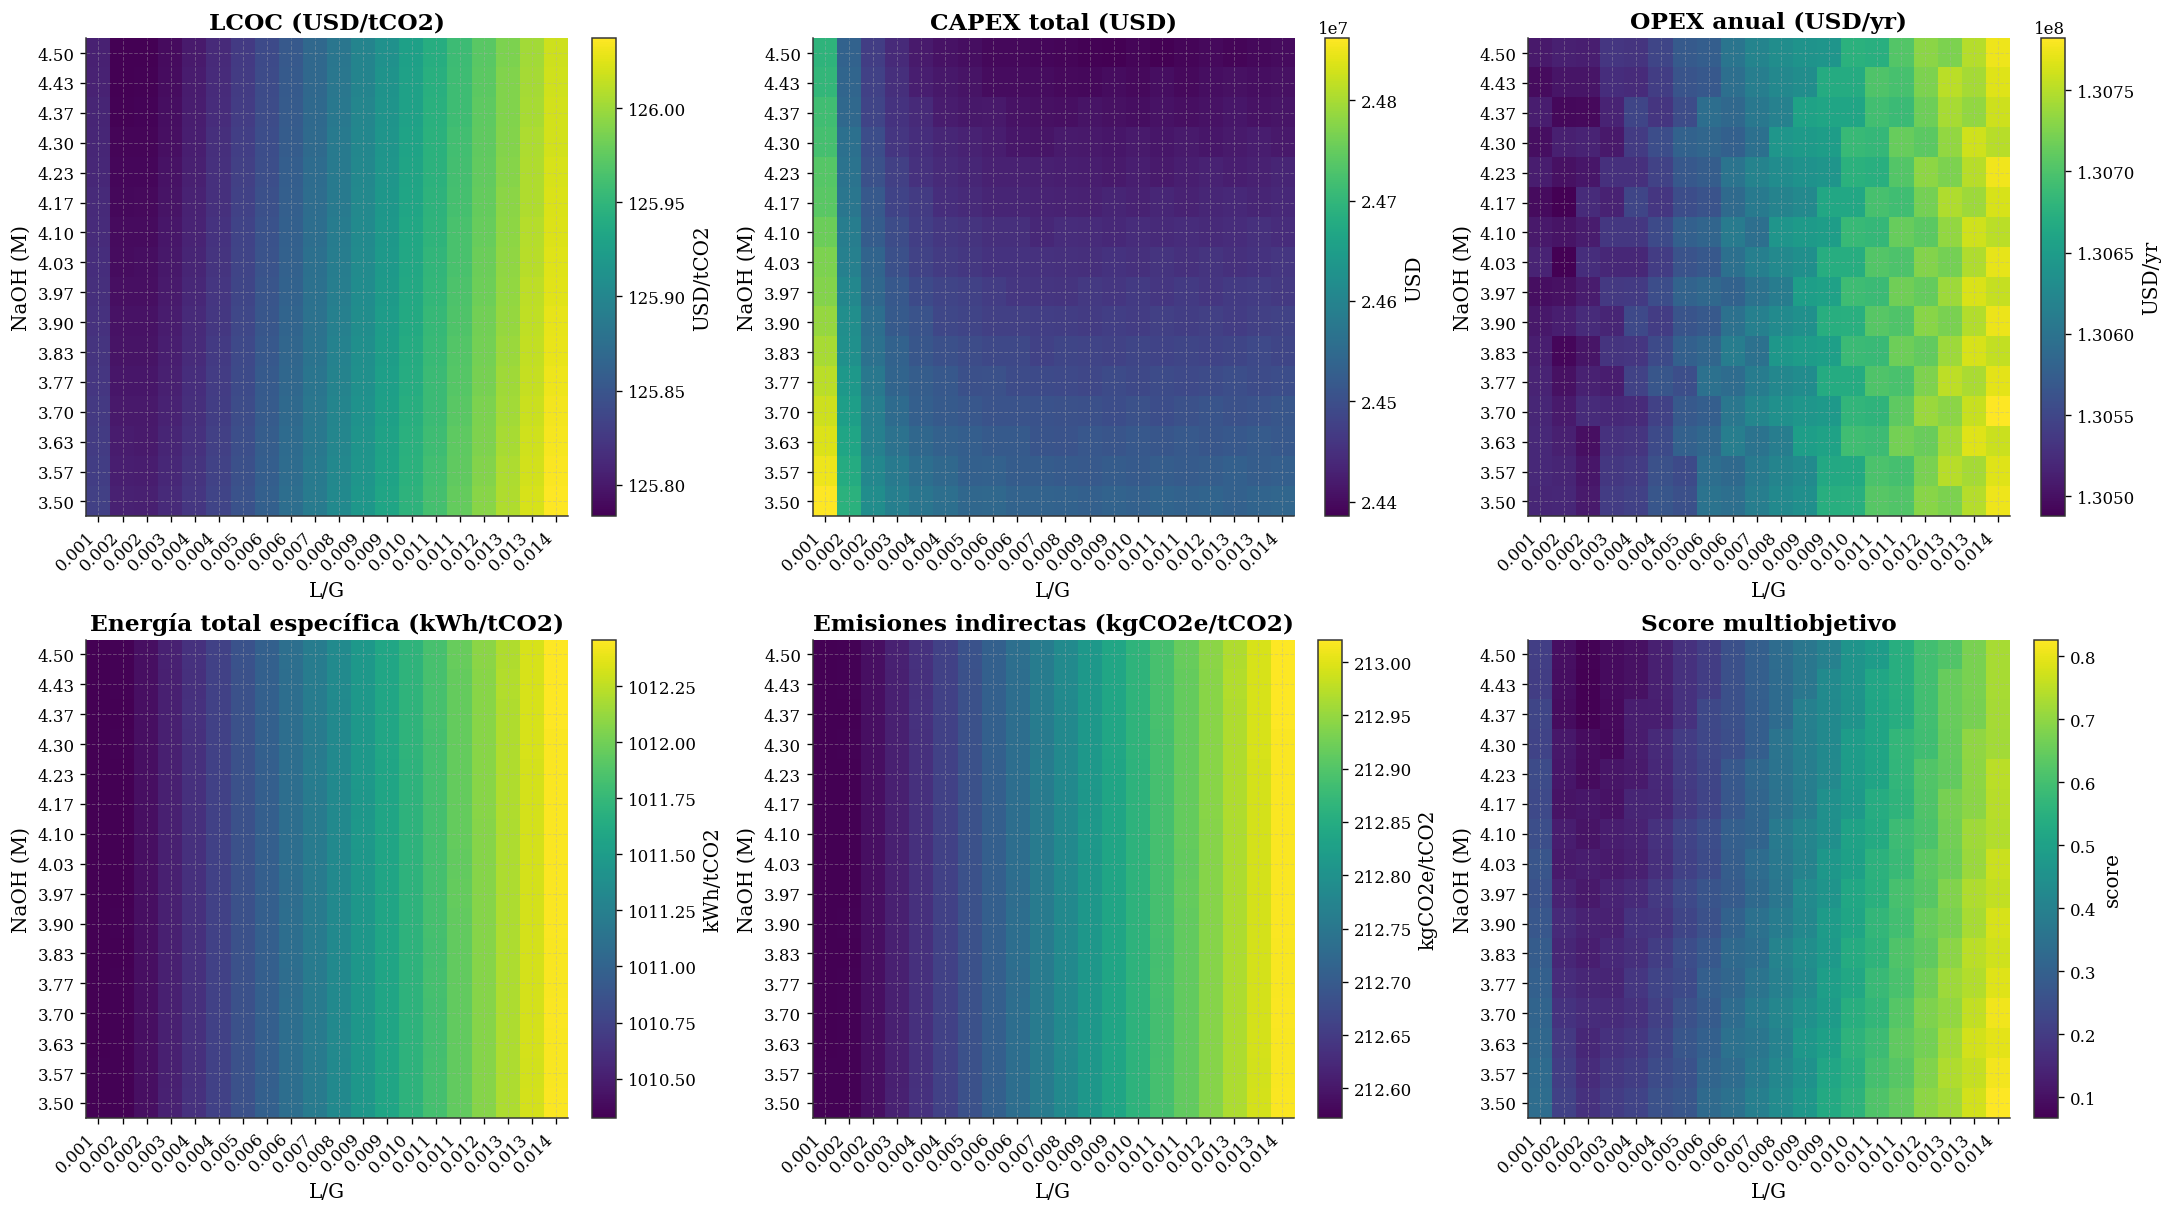

In [98]:
# ============================================================
# PLOTS: heatmaps for the 2D design space
# ============================================================

def make_pivot(df, value_col):
    if value_col not in df.columns:
        raise KeyError(f"Column '{value_col}' not found in dataframe.")
    tmp = df.pivot_table(
        index="NaOH_conc_M",
        columns="LG_vol",
        values=value_col,
        aggfunc="mean"
    )
    tmp = tmp.sort_index(axis=0).sort_index(axis=1)
    return tmp

# IMPORTANTE:
# usamos fine_ranked, no fine_ok, porque fine_ranked sí contiene 'score'
plots_df = fine_ranked.copy()

pivot_lcoc = make_pivot(plots_df, "LCOC_usd_per_tCO2")
pivot_capex = make_pivot(plots_df, "capex_total_usd")
pivot_opex = make_pivot(plots_df, "opex_total_usd_per_year")
pivot_energy = make_pivot(plots_df, "E_total_kWh_tCO2")
pivot_indirect = make_pivot(plots_df, "indirect_kgCO2e_per_tCO2")
pivot_score = make_pivot(plots_df, "score")

fig, axs = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

heatmaps = [
    (axs[0,0], pivot_lcoc, "LCOC (USD/tCO2)", "USD/tCO2"),
    (axs[0,1], pivot_capex, "CAPEX total (USD)", "USD"),
    (axs[0,2], pivot_opex, "OPEX anual (USD/yr)", "USD/yr"),
    (axs[1,0], pivot_energy, "Energía total específica (kWh/tCO2)", "kWh/tCO2"),
    (axs[1,1], pivot_indirect, "Emisiones indirectas (kgCO2e/tCO2)", "kgCO2e/tCO2"),
    (axs[1,2], pivot_score, "Score multiobjetivo", "score"),
]

for ax, pv, title, cbar_label in heatmaps:
    im = ax.imshow(
        pv.values,
        origin="lower",
        aspect="auto",
        interpolation="nearest"
    )
    ax.set_title(title)
    ax.set_xlabel("L/G")
    ax.set_ylabel("NaOH (M)")
    ax.set_xticks(np.arange(len(pv.columns)))
    ax.set_xticklabels([f"{x:.3f}" for x in pv.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pv.index)))
    ax.set_yticklabels([f"{x:.2f}" for x in pv.index])
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

plt.show()

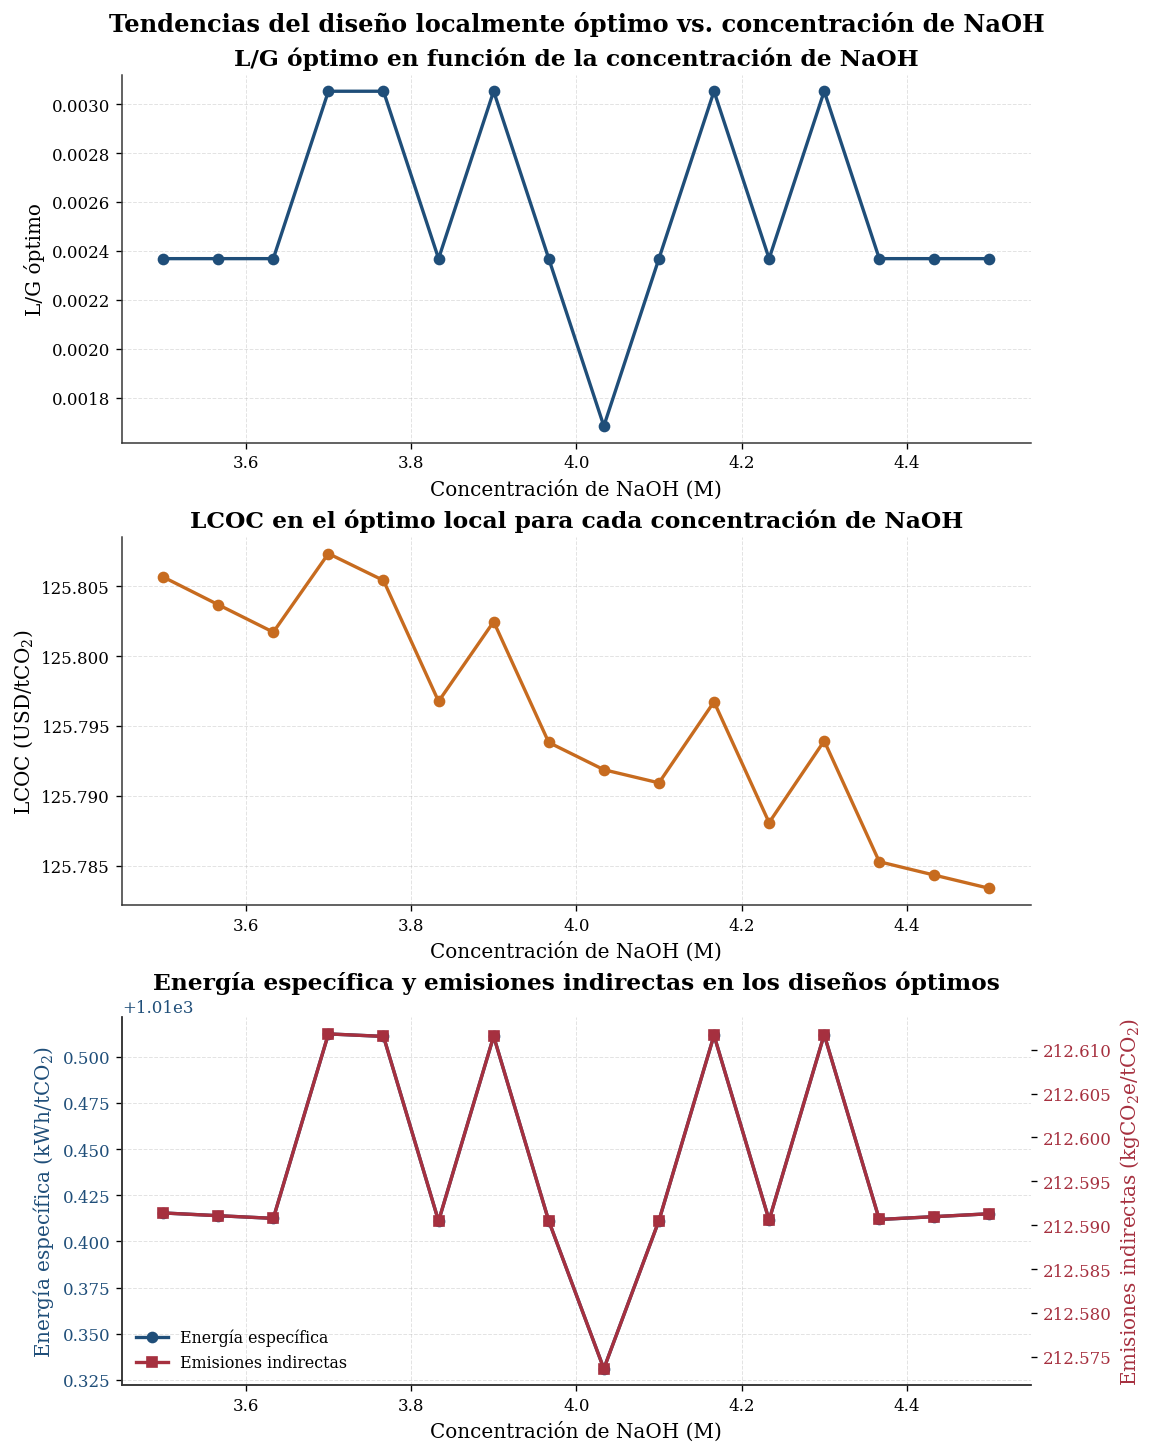

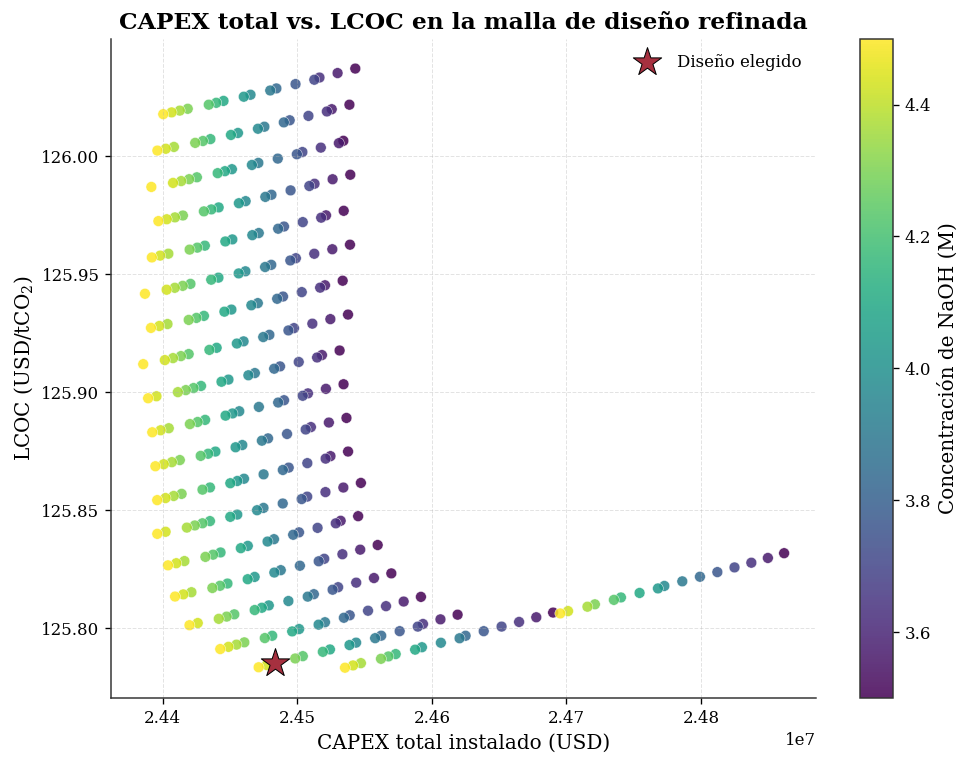

In [99]:
# ============================================================
# 1D OPTIMAL TRENDS + SIMPLE PARETO VISUALIZATION
# ============================================================

# Nos aseguramos de trabajar con el dataframe que sí tiene score
plots_df = fine_ranked.copy()

# Mejor L/G para cada concentración de NaOH (según score)
best_by_naoh = (
    plots_df.dropna(subset=["score"])
    .sort_values("score")
    .groupby("NaOH_conc_M", as_index=False)
    .first()
    .sort_values("NaOH_conc_M")
)

fig, axs = plt.subplots(3, 1, figsize=(9.5, 12), constrained_layout=True)

axs[0].plot(best_by_naoh["NaOH_conc_M"], best_by_naoh["LG_vol"], marker="o", color=PALETA["azul"], zorder=3)
axs[0].set_xlabel("Concentración de NaOH (M)")
axs[0].set_ylabel("L/G óptimo")
axs[0].set_title("L/G óptimo en función de la concentración de NaOH")

axs[1].plot(best_by_naoh["NaOH_conc_M"], best_by_naoh["LCOC_usd_per_tCO2"], marker="o", color=PALETA["naranja"], zorder=3)
axs[1].set_xlabel("Concentración de NaOH (M)")
axs[1].set_ylabel("LCOC (USD/tCO$_2$)")
axs[1].set_title("LCOC en el óptimo local para cada concentración de NaOH")

ax_e = axs[2]
ax_e.plot(best_by_naoh["NaOH_conc_M"], best_by_naoh["E_total_kWh_tCO2"], marker="o", color=PALETA["azul"], label="Energía específica", zorder=3)
ax_e.set_xlabel("Concentración de NaOH (M)")
ax_e.set_ylabel("Energía específica (kWh/tCO$_2$)", color=PALETA["azul"])
ax_e.tick_params(axis="y", labelcolor=PALETA["azul"])

ax_em = ax_e.twinx()
ax_em.plot(best_by_naoh["NaOH_conc_M"], best_by_naoh["indirect_kgCO2e_per_tCO2"], marker="s", color=PALETA["rojo"], label="Emisiones indirectas", zorder=3)
ax_em.set_ylabel("Emisiones indirectas (kgCO$_2$e/tCO$_2$)", color=PALETA["rojo"])
ax_em.tick_params(axis="y", labelcolor=PALETA["rojo"])
ax_em.grid(False)

l1, e1 = ax_e.get_legend_handles_labels(); l2, e2 = ax_em.get_legend_handles_labels()
ax_e.legend(l1 + l2, e1 + e2, loc="best", fontsize=9.5)
ax_e.set_title("Energía específica y emisiones indirectas en los diseños óptimos")

fig.suptitle("Tendencias del diseño localmente óptimo vs. concentración de NaOH", fontsize=14.5, fontweight="bold")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sc = ax.scatter(plots_df["capex_total_usd"], plots_df["LCOC_usd_per_tCO2"], c=plots_df["NaOH_conc_M"],
                 s=42, cmap="viridis", alpha=0.85, edgecolors="white", linewidths=0.3)
ax.scatter(best_fine["capex_total_usd"], best_fine["LCOC_usd_per_tCO2"], marker="*", s=320,
           color=PALETA["rojo"], edgecolors="black", linewidths=0.6, label="Diseño elegido", zorder=4)
ax.set_xlabel("CAPEX total instalado (USD)")
ax.set_ylabel("LCOC (USD/tCO$_2$)")
ax.set_title("CAPEX total vs. LCOC en la malla de diseño refinada")
cbar = fig.colorbar(sc, ax=ax); cbar.set_label("Concentración de NaOH (M)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

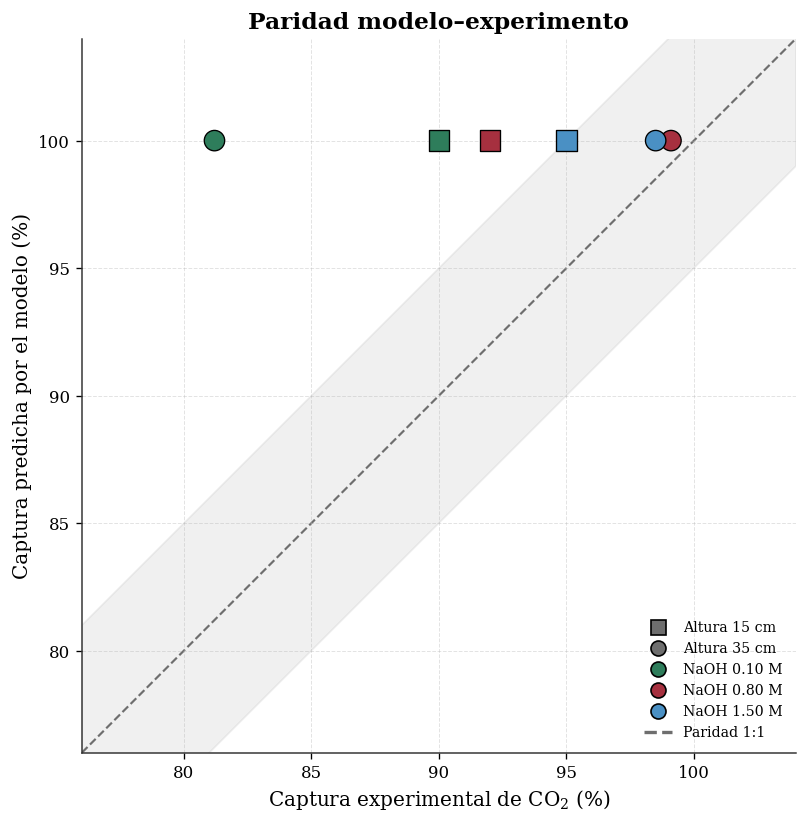

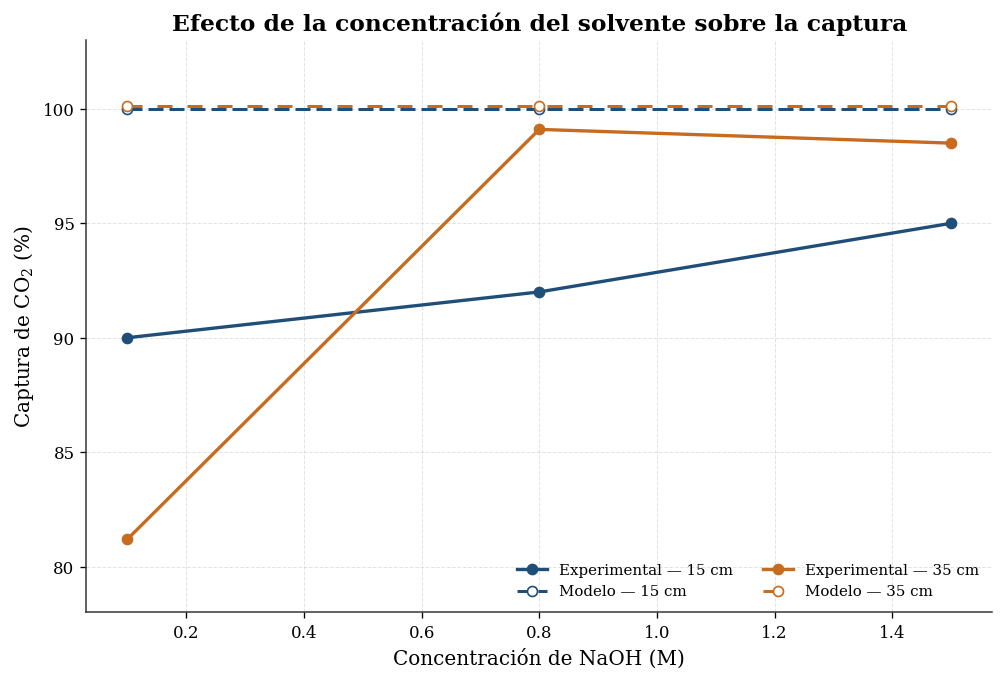

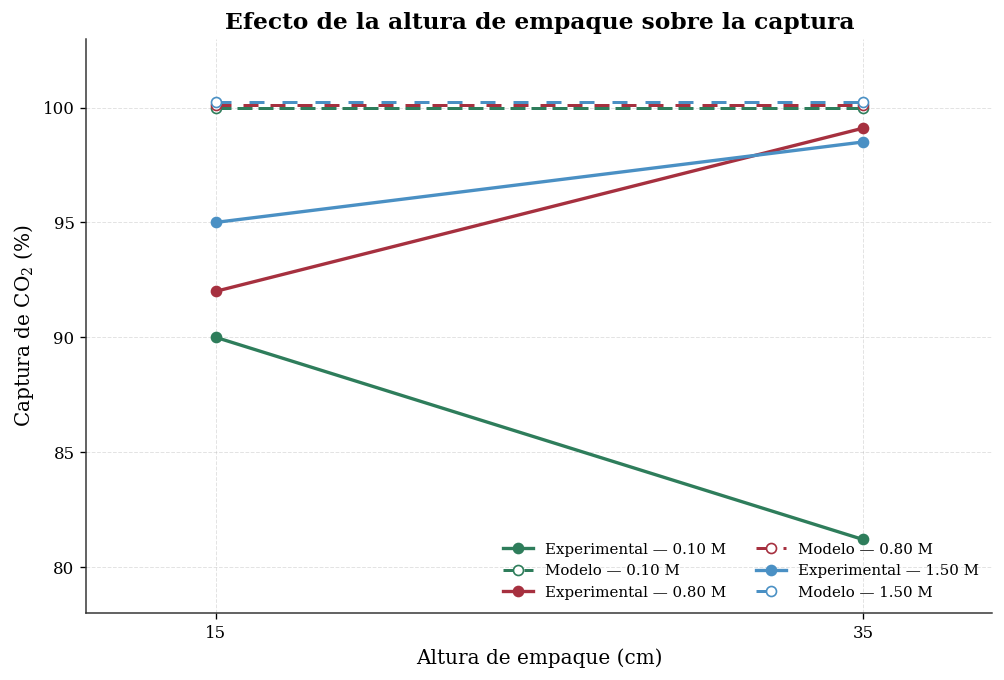

In [100]:
# ============================================================
# FIGURAS CAPÍTULO 5 — Comparación modelo vs. experimento
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

configurar_estilo_tesis()

# --- Datos (Cuadro 5.1, corridas NaOH). Edita aquí si cambian. ---
datos = {
    "conc_M":      np.array([0.10, 0.80, 1.50, 0.10, 0.80, 1.50]),
    "altura_cm":   np.array([  35,   35,   35,   15,   15,   15]),
    "exp_pct":     np.array([81.2, 99.1, 98.5, 90.0, 92.0, 95.0]),
    "modelo_pct":  np.array([100.0, 100.0, 100.0, 100.0, 100.0, 100.0]),
}

COLOR_ALTURA = {15: PALETA["azul"], 35: PALETA["naranja"]}
COLOR_CONC   = {0.10: PALETA["verde"], 0.80: PALETA["rojo"], 1.50: PALETA["azul_claro"]}


def fig_paridad(datos, guardar=None):
    """Paridad modelo-experimento, con banda de tolerancia y diagnóstico de degeneración."""
    exp, mod = datos["exp_pct"], datos["modelo_pct"]
    rmse = float(np.sqrt(np.mean((mod - exp) ** 2)))
    sesgo = float(np.mean(mod - exp))
    degenerado = np.ptp(mod) < 1e-6

    lo, hi = 76, 104
    fig, ax = plt.subplots(figsize=(7.8, 7.0))

    ax.fill_between([lo, hi], [lo - 5, hi - 5], [lo + 5, hi + 5],
                    color=PALETA["gris"], alpha=0.10, zorder=0, label="Banda $\\pm$5 pp")
    ax.plot([lo, hi], [lo, hi], linestyle="--", color=PALETA["gris"], linewidth=1.3,
            zorder=1, label="Paridad 1:1")

    for h, marcador in [(15, "s"), (35, "o")]:
        m = datos["altura_cm"] == h
        ax.scatter(exp[m], mod[m], marker=marcador, s=150, c=[COLOR_CONC[c] for c in datos["conc_M"][m]],
                   edgecolors="black", linewidths=0.8, zorder=3)

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Captura experimental de CO$_2$ (%)")
    ax.set_ylabel("Captura predicha por el modelo (%)")
    ax.set_title("Paridad modelo–experimento")


    leyenda = [Line2D([], [], marker="s", linestyle="", color=PALETA["gris"], markersize=9,
                      markeredgecolor="black", label="Altura 15 cm"),
               Line2D([], [], marker="o", linestyle="", color=PALETA["gris"], markersize=9,
                      markeredgecolor="black", label="Altura 35 cm")]
    leyenda += [Line2D([], [], marker="o", linestyle="", color=COLOR_CONC[c], markersize=9,
                       markeredgecolor="black", label=f"NaOH {c:.2f} M") for c in [0.10, 0.80, 1.50]]
    leyenda += [Line2D([], [], linestyle="--", color=PALETA["gris"], label="Paridad 1:1")]
    ax.legend(handles=leyenda, loc="lower right", fontsize=8.5, ncol=1)

    fig.tight_layout()
    if guardar: fig.savefig(guardar, dpi=300, bbox_inches="tight")
    plt.show()


def fig_efecto_concentracion(datos, guardar=None):
    """Captura vs. concentración de NaOH, una serie por altura de empaque."""
    fig, ax = plt.subplots(figsize=(8.5, 5.8))

    for i, h in enumerate([15, 35]):
        m = datos["altura_cm"] == h
        orden = np.argsort(datos["conc_M"][m])
        c = datos["conc_M"][m][orden]
        ax.plot(c, datos["exp_pct"][m][orden], marker="o", color=COLOR_ALTURA[h],
                label=f"Experimental — {h} cm", zorder=3)
        ax.plot(c, datos["modelo_pct"][m][orden] + i * 0.12, marker="o", markerfacecolor="white",
                color=COLOR_ALTURA[h], linestyle=(0, (5, 2 + 3 * i)), linewidth=1.8,
                label=f"Modelo — {h} cm", zorder=2)

    ax.set_xlabel("Concentración de NaOH (M)")
    ax.set_ylabel("Captura de CO$_2$ (%)")
    ax.set_title("Efecto de la concentración del solvente sobre la captura")
    ax.set_ylim(78, 103)
    ax.legend(loc="lower right", fontsize=9, ncol=2)
    fig.tight_layout()
    if guardar: fig.savefig(guardar, dpi=300, bbox_inches="tight")
    plt.show()


def fig_efecto_altura(datos, guardar=None):
    """Captura vs. altura de empaque, una serie por concentración de NaOH."""
    fig, ax = plt.subplots(figsize=(8.5, 5.8))

    for i, c in enumerate([0.10, 0.80, 1.50]):
        m = datos["conc_M"] == c
        orden = np.argsort(datos["altura_cm"][m])
        h = datos["altura_cm"][m][orden]
        ax.plot(h, datos["exp_pct"][m][orden], marker="o", color=COLOR_CONC[c],
                label=f"Experimental — {c:.2f} M", zorder=3)
        ax.plot(h, datos["modelo_pct"][m][orden] + i * 0.12, marker="o", markerfacecolor="white",
                color=COLOR_CONC[c], linestyle=(0, (5, 2 + 2 * i)), linewidth=1.8,
                label=f"Modelo — {c:.2f} M", zorder=2)

    ax.set_xlabel("Altura de empaque (cm)")
    ax.set_ylabel("Captura de CO$_2$ (%)")
    ax.set_title("Efecto de la altura de empaque sobre la captura")
    ax.set_xticks([15, 35]); ax.set_xlim(11, 39); ax.set_ylim(78, 103)
    ax.legend(loc="lower right", fontsize=9, ncol=2)
    fig.tight_layout()
    if guardar: fig.savefig(guardar, dpi=300, bbox_inches="tight")
    plt.show()


fig_paridad(datos,               guardar="fig_paridad_modelo_exp.png")
fig_efecto_concentracion(datos,  guardar="fig_efecto_concentracion.png")
fig_efecto_altura(datos,         guardar="fig_efecto_altura.png")

In [101]:
# --- Parámetros REALES del banco (Sección 5.2–5.3 de la tesis) ---
Q_CO2_mL_min = 500.0
Q_N2_mL_min  = 2600.0
Q_total_mL_min = Q_CO2_mL_min + Q_N2_mL_min          # 3100 mL/min

# Los caudalímetros midieron a 25°C/1 atm; se corrige a Nm3/h (referencia 0°C/1 atm)
Q_total_Nm3h = (Q_total_mL_min / 1e6) * 60.0 * (273.15 / 298.15)   # ≈ 0.1704 Nm3/h
yCO2_banco = Q_CO2_mL_min / Q_total_mL_min                          # = 0.16129
yO2_banco  = 0.0                                                    # mezcla sintética, sin O2

LG_banco = 383.0 / Q_total_mL_min   # 0.1235, coincide con el "≈0.124" que ya reportas en 5.2.2

print(f"Q_total_Nm3h = {Q_total_Nm3h:.5f} | yCO2 = {yCO2_banco:.4f} | L/G = {LG_banco:.4f}")

# --- Corre cada corrida a su ALTURA FÍSICA REAL, no a un objetivo de captura ---
for H_real_m, C_NaOH in [(0.15, 0.10), (0.15, 0.80), (0.15, 1.50),
                          (0.35, 0.10), (0.35, 0.80), (0.35, 1.50)]:

    resultado = simulate_absorber_fixed_diameter(
        Qg_Nm3h=Q_total_Nm3h,
        yCO2_dry_in=yCO2_banco,
        yO2_dry_in=yO2_banco,
        T_gas_abs_C=25.0,
        P_abs_bar=1.01,
        capture_target=0.999999,      # <- truco: nunca se alcanza antes de H_real_m
        NaOH_conc_M=C_NaOH,
        LG_vol=LG_banco,
        packing_name="pall_ring_25mm",  # <- VERIFICA: si tu TPMS tiene otra geometría en PACKINGS, cámbialo aquí
        H_eq=0.04,
        max_height_m=H_real_m,        # <- la altura FÍSICA real, no una a calcular
        dz=0.02,
        D_col_m=0.0154,           # <- el diámetro real de tu torre (ya lo tienes bien)
    )

    G = resultado["G_molar"]
    KGa = resultado["KGa"]
    H = resultado["height_m"]
    NTU = (KGa / max(G, 1e-12)) * H
    captura = resultado["capture_achieved"] * 100

    print(f"H={H_real_m*100:.0f}cm  NaOH={C_NaOH:.2f}M | "
          f"G_molar={G:.4e} mol/s | KGa={KGa:.2f} 1/s | NTU={NTU:.2f} | "
          f"captura modelo={captura:.1f}%")

Q_total_Nm3h = 0.17040 | yCO2 = 0.1613 | L/G = 0.1235
KGa=0.083 1/s | G_molar=2.180e-03 mol/s | (KGa/G)*dz = 0.77
H=15cm  NaOH=0.10M | G_molar=2.1800e-03 mol/s | KGa=0.08 1/s | NTU=6.13 | captura modelo=99.8%
KGa=0.084 1/s | G_molar=2.180e-03 mol/s | (KGa/G)*dz = 0.77
H=15cm  NaOH=0.80M | G_molar=2.1800e-03 mol/s | KGa=0.08 1/s | NTU=6.13 | captura modelo=99.8%
KGa=0.084 1/s | G_molar=2.180e-03 mol/s | (KGa/G)*dz = 0.77
H=15cm  NaOH=1.50M | G_molar=2.1800e-03 mol/s | KGa=0.08 1/s | NTU=6.13 | captura modelo=99.8%
KGa=0.083 1/s | G_molar=2.180e-03 mol/s | (KGa/G)*dz = 0.77
H=35cm  NaOH=0.10M | G_molar=2.1800e-03 mol/s | KGa=0.08 1/s | NTU=13.79 | captura modelo=100.0%
KGa=0.084 1/s | G_molar=2.180e-03 mol/s | (KGa/G)*dz = 0.77
H=35cm  NaOH=0.80M | G_molar=2.1800e-03 mol/s | KGa=0.08 1/s | NTU=13.80 | captura modelo=100.0%
KGa=0.084 1/s | G_molar=2.180e-03 mol/s | (KGa/G)*dz = 0.77
H=35cm  NaOH=1.50M | G_molar=2.1800e-03 mol/s | KGa=0.08 1/s | NTU=13.80 | captura modelo=100.0%
